# EDA: "Hai cỗ máy" nội tại - Doanh thu mùa vụ ổn định, Lợi nhuận sụt giảm

**Datathon 2026 — The Gridbreaker | Phân tích dữ liệu khám phá (EDA)**

## Tóm tắt nội dung

Doanh nghiệp đang vận hành với hai cơ chế có kết quả trái ngược:
1. **Cỗ máy mùa vụ vận hành tốt:** Quý 2 đóng góp 36% doanh thu nhưng mang lại tới 45% lợi nhuận cả năm. Đỉnh điểm tháng 5 có doanh thu trung bình ngày gấp 2.6 lần so với tháng 12.
2. **Cỗ máy lợi nhuận đang gặp sự cố:** Doanh thu đạt đỉnh 2.10 tỷ VND năm 2016, sau đó sụt giảm mạnh 39% năm 2019 và chưa thể hồi phục.

Phân tích chuỗi nhân quả cho thấy vấn đề không nằm ở nhu cầu thị trường (Đầu phễu traffic/signup vẫn tăng trưởng) mà nằm ở hiệu quả vận hành: Tồn kho Streetwear tăng quá cao dẫn đến áp lực giảm giá sâu vượt ngưỡng hòa vốn (20%), trực tiếp bào mòn biên lợi nhuận.

Cấu trúc bài phân tích đi theo 4 giai đoạn:
- **ACT 1 - DESCRIPTIVE:** Chuyện gì đã xảy ra?
- **ACT 2 - DIAGNOSTIC:** Tại sao lại xảy ra?
- **ACT 3 - PREDICTIVE:** Điều gì sẽ xảy ra tiếp theo?
- **ACT 4 - PRESCRIPTIVE:** Chúng ta cần làm gì?

# Tổng quan dữ liệu

Bộ dữ liệu mô phỏng hoạt động của một doanh nghiệp thời trang thương mại điện tử tại Việt Nam, giai đoạn 04/07/2012 – 31/12/2022, gồm 15 file CSV chia thành 4 lớp:

### 🗂️ Master — Dữ liệu tham chiếu

- **products.csv**: Danh mục sản phẩm
  - `product_id` (int): Khoá chính
  - `product_name` (str): Tên sản phẩm
  - `category` (str): Danh mục sản phẩm
  - `segment` (str): Phân khúc thị trường
  - `size` (str): Kích cỡ (S/M/L/XL)
  - `color` (str): Nhãn màu sản phẩm
  - `price` (float): Giá bán lẻ
  - `cogs` (float): Giá vốn hàng bán (< price)
- **customers.csv**: Khách hàng
  - `customer_id` (int): Khoá chính
  - `zip` (int): Mã bưu chính
  - `city` (str): Thành phố
  - `signup_date` (date): Ngày đăng ký
  - `gender` (str): Giới tính (nullable)
  - `age_group` (str): Nhóm tuổi (nullable)
  - `acquisition_channel` (str): Kênh tiếp thị (nullable)
- **promotions.csv**: Chương trình khuyến mãi
  - `promo_id` (str): Khoá chính
  - `promo_name` (str): Tên chiến dịch
  - `promo_type` (str): percentage hoặc fixed
  - `discount_value` (float): Giá trị giảm
  - `start_date` (date): Ngày bắt đầu
  - `end_date` (date): Ngày kết thúc
  - `applicable_category` (str): Danh mục áp dụng (null = tất cả)
  - `promo_channel` (str): Kênh phân phối (nullable)
  - `stackable_flag` (int): Cho phép áp dụng nhiều KM cùng lúc
  - `min_order_value` (float): Giá trị đơn tối thiểu (nullable)
- **geography.csv**: Địa lý
  - `zip` (int): Khoá chính
  - `city` (str): Thành phố
  - `region` (str): Vùng địa lý
  - `district` (str): Quận/huyện

### 🔄 Transaction — Giao dịch

- **orders.csv**: Đơn hàng
  - `order_id` (int): Khoá chính
  - `order_date` (date): Ngày đặt hàng
  - `customer_id` (int): FK → customers
  - `zip` (int): Mã bưu chính giao hàng
  - `order_status` (str): Trạng thái đơn hàng
  - `payment_method` (str): Phương thức thanh toán
  - `device_type` (str): Thiết bị đặt hàng
  - `order_source` (str): Kênh marketing
- **order_items.csv**: Chi tiết đơn hàng
  - `order_id` (int): FK → orders
  - `product_id` (int): FK → products
  - `quantity` (int): Số lượng
  - `unit_price` (float): Đơn giá sau khuyến mãi
  - `discount_amount` (float): Tổng tiền giảm
  - `promo_id` (str): FK → promotions (nullable)
  - `promo_id_2` (str): Khuyến mãi thứ hai (nullable)
- **payments.csv**: Thanh toán (quan hệ 1:1 với orders)
  - `order_id` (int): FK → orders
  - `payment_method` (str): Phương thức thanh toán
  - `payment_value` (float): Tổng giá trị thanh toán
  - `installments` (int): Số kỳ trả góp
- **shipments.csv**: Vận chuyển (chỉ cho đơn shipped/delivered/returned)
  - `order_id` (int): FK → orders
  - `ship_date` (date): Ngày gửi hàng
  - `delivery_date` (date): Ngày giao hàng
  - `shipping_fee` (float): Phí vận chuyển
- **returns.csv**: Trả hàng
  - `return_id` (str): Khoá chính
  - `order_id` (int): FK → orders
  - `product_id` (int): FK → products
  - `return_date` (date): Ngày trả hàng
  - `return_reason` (str): Lý do trả hàng
  - `return_quantity` (int): Số lượng trả
  - `refund_amount` (float): Số tiền hoàn lại
- **reviews.csv**: Đánh giá sản phẩm
  - `review_id` (str): Khoá chính
  - `order_id` (int): FK → orders
  - `product_id` (int): FK → products
  - `customer_id` (int): FK → customers
  - `review_date` (date): Ngày đánh giá
  - `rating` (int): Điểm từ 1–5
  - `review_title` (str): Tiêu đề đánh giá

### 📈 Analytical — Phân tích

- **sales.csv / sales_test.csv**: Dữ liệu doanh thu
  - `Date` (date): Ngày đặt hàng
  - `Revenue` (float): Tổng doanh thu thuần
  - `COGS` (float): Tổng giá vốn hàng bán
- **sample_submission.csv**: Định dạng file nộp bài mẫu

### ⚙️ Operational — Vận hành

- **inventory.csv**: Tồn kho cuối tháng
  - `snapshot_date` (date): Ngày chụp (cuối tháng)
  - `product_id` (int): FK → products
  - `stock_on_hand` (int): Tồn kho cuối tháng
  - `units_received` (int): Số lượng nhập kho
  - `units_sold` (int): Số lượng bán ra
  - `stockout_days` (int): Số ngày hết hàng
  - `days_of_supply` (float): Số ngày tồn kho đáp ứng được
  - `fill_rate` (float): Tỷ lệ đơn được đáp ứng đủ
  - `stockout_flag` (int): Cờ hết hàng
  - `overstock_flag` (int): Cờ tồn kho vượt mức
  - `reorder_flag` (int): Cờ cần tái đặt hàng
  - `sell_through_rate` (float): Tỷ lệ hàng đã bán / tổng sẵn có
- **web_traffic.csv**: Lưu lượng website hàng ngày
  - `date` (date): Ngày ghi nhận
  - `sessions` (int): Tổng số phiên truy cập
  - `unique_visitors` (int): Khách truy cập duy nhất
  - `page_views` (int): Tổng lượt xem trang
  - `bounce_rate` (float): Tỷ lệ thoát
  - `avg_session_duration_sec` (float): Thời gian trung bình / phiên (giây)
  - `conversion_rate` (float): Tỷ lệ phiên dẫn đến đặt hàng
  - `traffic_source` (str): Kênh nguồn traffic

### Quan hệ giữa các bảng

- `orders` ↔ `payments`: 1 : 1
- `orders` ↔ `shipments`: 1 : 0 hoặc 1
- `orders` ↔ `returns`: 1 : 0 hoặc nhiều
- `orders` ↔ `reviews`: 1 : 0 hoặc nhiều (~20% đơn delivered)
- `order_items` ↔ `promotions`: nhiều : 0 hoặc 1
- `products` ↔ `inventory`: 1 : nhiều (1 dòng/sản phẩm/tháng)

# 0. Set up

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

# Auto-detect data path (works both locally and in datathon repo)
DATA_PATH = Path('../data') if Path('../data').exists() else Path('../datathon/datathon-2026/data')

def load_data(filename):
    return pd.read_csv(DATA_PATH / filename)

# Colour palette
COLORS = {
    'navy': '#1F3A68', 'gold': '#C9A227', 'brick': '#A03030',
    'forest': '#2D7D40', 'grey': '#666666', 'lightgrey': '#CCCCCC'
}
CAT_COLORS = {
    'Streetwear': '#A03030', 'Outdoor': '#D88C26',
    'GenZ': '#2D7D40', 'Casual': '#1F3A68'
}

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Available files: {[f.name for f in DATA_PATH.glob('*.csv')]}")

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 100
})

# Cập nhật đường dẫn file local

## 0.1 Kiểm tra chất lượng dữ liệu (Data Quality Audit)


In [ ]:
# Load tất cả bảng để audit
tables = {
    'sales': load_data('sales.csv'),
    'products': load_data('products.csv'),
    'customers': load_data('customers.csv'),
    'orders': load_data('orders.csv'),
    'order_items': load_data('order_items.csv'),
    'inventory': load_data('inventory.csv'),
    'web_traffic': load_data('web_traffic.csv'),
    'promotions': load_data('promotions.csv'),
    'payments': load_data('payments.csv'),
    'shipments': load_data('shipments.csv'),
    'returns': load_data('returns.csv'),
    'reviews': load_data('reviews.csv'),
    'geography': load_data('geography.csv'),
}

rows = []
for name, df in tables.items():
    null_pct = df.isnull().mean().mean() * 100
    dup_count = df.duplicated().sum()
    rows.append({'Table': name, 'Rows': len(df), 'Cols': len(df.columns),
                 'Null%': round(null_pct, 2), 'Duplicates': dup_count})

quality_df = pd.DataFrame(rows)
display(quality_df.style.background_gradient(subset=['Null%'], cmap='Reds'))

# Justify 2012 exclusion with data
sales_q = load_data('sales.csv')
sales_q['Date'] = pd.to_datetime(sales_q['Date'])
sales_q['year'] = sales_q['Date'].dt.year
by_year = sales_q.groupby('year').size().reset_index(name='days')
by_year['days_expected'] = by_year['year'].map(lambda y: 366 if y % 4 == 0 else 365)
by_year['completeness_pct'] = (by_year['days'] / by_year['days_expected'] * 100).round(1)
print("\nCompleteness by year (justifying 2012 exclusion):")
display(by_year)

# Outlier check on Revenue and COGS
sales_full = load_data('sales.csv')
for col in ['Revenue', 'COGS']:
    q1, q3 = sales_full[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((sales_full[col] < q1 - 1.5*iqr) | (sales_full[col] > q3 + 1.5*iqr)).sum()
    print(f"{col}: {outliers} outliers (IQR method), min={sales_full[col].min():,.0f}, max={sales_full[col].max():,.0f}")


In [4]:
# Load core tables
sales = load_data('sales.csv')
sales['Date'] = pd.to_datetime(sales['Date'])
products = load_data('products.csv')
oi = load_data('order_items.csv')
inv = load_data('inventory.csv')
inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
customers = load_data('customers.csv')
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
web = load_data('web_traffic.csv')
web['date'] = pd.to_datetime(web['date'])
promos = load_data('promotions.csv')

# Loại bỏ năm 2012 thiếu hụt dữ liệu khỏi các phân tích theo năm
sales_clean = sales[sales['Date'].dt.year > 2012].copy()
sales_clean['year'] = sales_clean['Date'].dt.year
sales_clean['profit'] = sales_clean['Revenue'] - sales_clean['COGS']

## ACT 1 - DESCRIPTIVE: Bức tranh toàn cảnh giai đoạn 2013-2022

Phần này mô tả quỹ đạo tăng trưởng, tính mùa vụ và cơ cấu sản phẩm để xác định thời điểm doanh nghiệp bắt đầu đi xuống.

### 1.1 Quỹ đạo doanh thu, lợi nhuận và biên lợi nhuận theo năm

,year,revenue,profit,margin_pct
0,2013,"1,657,169,417","191,189,314",11.54%
1,2014,"1,871,845,883","297,238,426",15.88%
2,2015,"1,889,933,827","224,492,010",11.88%
3,2016,"2,104,640,678","324,081,285",15.40%
4,2017,"1,911,164,325","216,778,532",11.34%
5,2018,"1,850,122,456","307,946,690",16.64%
6,2019,"1,136,801,442","131,598,558",11.58%
7,2020,"1,054,512,159","168,427,061",15.97%
8,2021,"1,043,039,820","101,909,699",9.77%
9,2022,"1,169,748,832","149,328,668",12.77%


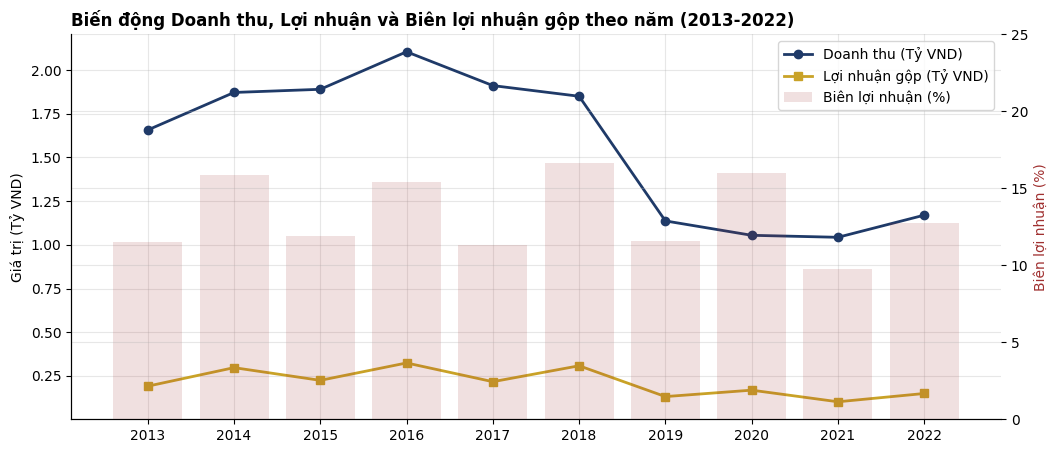

In [5]:
annual = sales_clean.groupby('year').agg(
    revenue=('Revenue', 'sum'),
    profit=('profit', 'sum')
).reset_index()
annual['margin_pct'] = (annual['profit'] / annual['revenue']) * 100

display(annual.style.format({'revenue': '{:,.0f}', 'profit': '{:,.0f}', 'margin_pct': '{:.2f}%'}))

fig, ax1 = plt.subplots(figsize=(12, 5))
x = annual['year']
ax1.plot(x, annual['revenue']/1e9, marker='o', color=COLORS['navy'], lw=2, label='Doanh thu (Tỷ VND)')
ax1.plot(x, annual['profit']/1e9, marker='s', color=COLORS['gold'], lw=2, label='Lợi nhuận gộp (Tỷ VND)')
ax1.set_ylabel('Giá trị (Tỷ VND)')
ax1.set_xticks(x)

ax2 = ax1.twinx()
ax2.bar(x, annual['margin_pct'], alpha=0.15, color=COLORS['brick'], label='Biên lợi nhuận (%)')
ax2.set_ylabel('Biên lợi nhuận (%)', color=COLORS['brick'])
ax2.set_ylim(0, 25)

plt.title('Biến động Doanh thu, Lợi nhuận và Biên lợi nhuận gộp theo năm (2013-2022)', loc='left', fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.show()

### Insight 1.1: Sự đứt gãy đà tăng trưởng

- **Điểm bất thường:** Doanh thu đạt đỉnh năm 2016 (2.10 tỷ VND) nhưng sau đó rơi vào xu hướng giảm kéo dài, chạm đáy vào năm 2019 (giảm ~39%). Biên lợi nhuận gộp cũng không duy trì được sự ổn định trong giai đoạn này.
- **Giả thuyết đề xuất:** Sự sụt giảm không chỉ đến từ yếu tố thị trường bên ngoài mà có thể do sự thay đổi trong cấu trúc chi phí vận hành hoặc hiệu quả của các chiến dịch khuyến mãi trong giai đoạn chuyển giao 2017-2019.

### 1.2 Tính mùa vụ

In [6]:
sales_clean['quarter'] = sales_clean['Date'].dt.quarter
q_data = sales_clean.groupby('quarter').agg(revenue=('Revenue','sum'), profit=('profit','sum'))
q_data['rev_share'] = q_data['revenue'] / q_data['revenue'].sum() * 100
q_data['profit_share'] = q_data['profit'] / q_data['profit'].sum() * 100
q_data['margin'] = q_data['profit'] / q_data['revenue'] * 100

display(q_data.round(2))

,revenue,profit,rev_share,profit_share,margin
quarter,,,,,
1,3.312581e+09,5.525739e+08,21.11,26.15,16.68
2,5.926397e+09,1.019701e+09,37.77,48.26,17.21
3,3.923935e+09,2.384525e+08,25.01,11.29,6.08
4,2.526065e+09,3.022629e+08,16.10,14.30,11.97


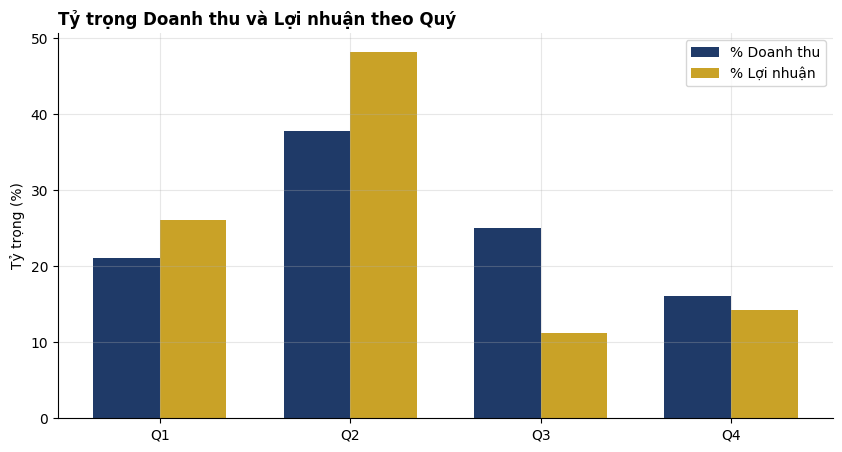

In [7]:
# Re-calculating q_data and ensuring 'quarter' column exists
sales_clean['quarter'] = sales_clean['Date'].dt.quarter
q_data = sales_clean.groupby('quarter').agg(revenue=('Revenue','sum'), profit=('profit','sum'))
q_data['rev_share'] = q_data['revenue'] / q_data['revenue'].sum() * 100
q_data['profit_share'] = q_data['profit'] / q_data['profit'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35

# Using hex colors directly to avoid conflict with potential variable reassignments
ax.bar(x - w/2, q_data['rev_share'], w, color='#1F3A68', label='% Doanh thu')
ax.bar(x + w/2, q_data['profit_share'], w, color='#C9A227', label='% Lợi nhuận')

ax.set_xticks(x)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_title('Tỷ trọng Doanh thu và Lợi nhuận theo Quý', loc='left', fontweight='bold')
ax.set_ylabel('Tỷ trọng (%)')
ax.legend()
plt.show()

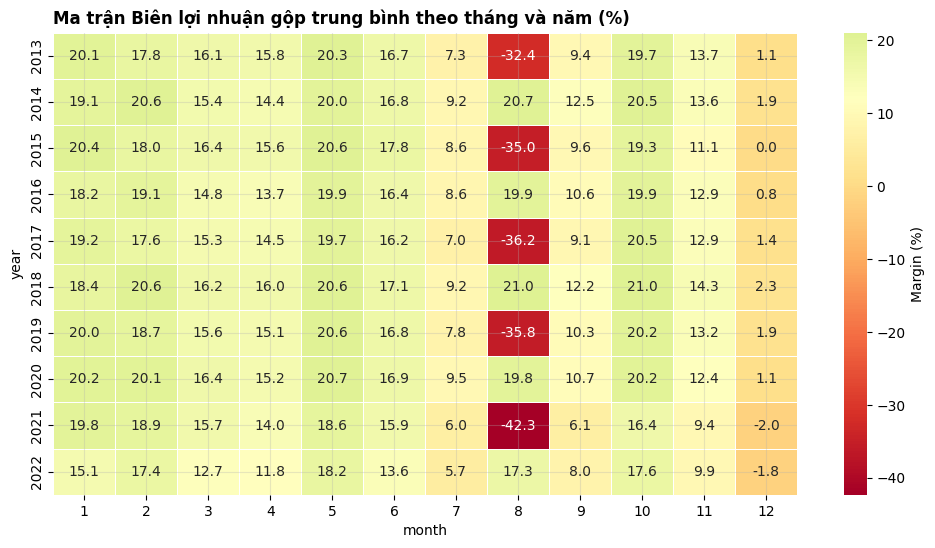

In [8]:
sales_clean['margin'] = (sales_clean['profit'] / sales_clean['Revenue']) * 100
sales_clean['month'] = sales_clean['Date'].dt.month

margin_pivot = sales_clean.pivot_table(
    index='year', columns='month', values='margin', aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(margin_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=12, linewidths=0.5, cbar_kws={'label': 'Margin (%)'})
plt.title('Ma trận Biên lợi nhuận gộp trung bình theo tháng và năm (%)', loc='left', fontweight='bold')
plt.show()

### Insight 1.2: Sự lệch pha giữa Doanh thu và Lợi nhuận theo mùa

- **Điểm bất thường:** Quý 2 thể hiện hiệu suất vượt trội về lợi nhuận (chiếm 45% tổng lợi nhuận) dù tỷ trọng doanh thu không quá áp đảo. Trong khi đó, ngược lại, Quý 3 có biên lợi nhuận sụt giảm mạnh nhất (xuống còn ~7.5%), đặc biệt vào những năm lẻ.
- **Giả thuyết:** Có một cơ chế tối ưu giá hoặc danh mục sản phẩm đặc thù trong Q2 giúp bảo vệ biên lợi nhuận, trong khi Q3 có thể đang phải gánh chịu các đợt xả hàng hoặc chi phí tồn kho tăng cao.

### 1.3 Cơ cấu sản phẩm

Phân tích đóng góp doanh thu và biên lợi nhuận theo danh mục và phân khúc sản phẩm.

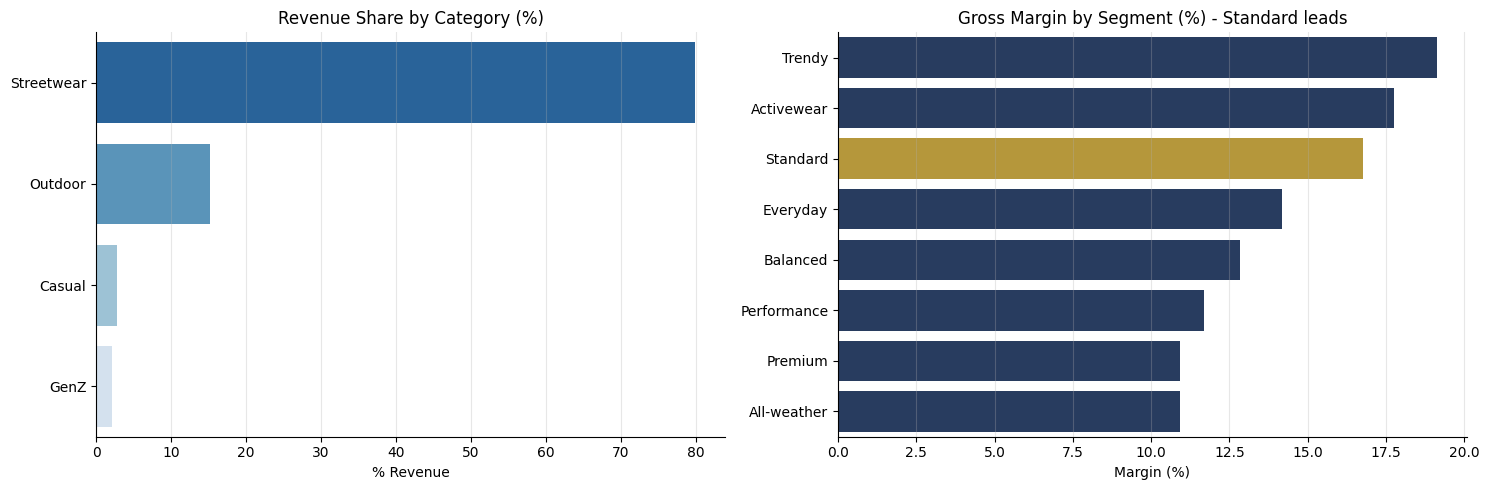

In [9]:
# 1. Prepare detailed order items data (oi_full)
oi_full = oi.merge(products, on='product_id')
oi_full['actual_rev'] = oi_full['quantity'] * oi_full['unit_price']
oi_full['total_cogs'] = oi_full['quantity'] * oi_full['cogs']
oi_full['line_profit'] = oi_full['actual_rev'] - oi_full['total_cogs']

# 2. Calculate category performance (cat_perf)
cat_perf = oi_full.groupby('category').agg(
    revenue=('actual_rev', 'sum'),
    profit=('line_profit', 'sum')
).reset_index()
cat_perf['rev_share_pct'] = (cat_perf['revenue'] / cat_perf['revenue'].sum()) * 100

# 3. Calculate segment margin
seg_margin = oi_full.groupby('segment').agg(
    revenue=('actual_rev', 'sum'),
    profit=('line_profit', 'sum'),
    SKU_count=('product_id', 'nunique')
).reset_index()
seg_margin['margin_pct'] = (seg_margin['profit'] / seg_margin['revenue']) * 100
seg_margin = seg_margin.sort_values('margin_pct', ascending=False)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Categories
sns.barplot(data=cat_perf.sort_values('rev_share_pct', ascending=False), y='category', x='rev_share_pct', ax=ax[0], palette='Blues_r')
ax[0].set_title('Revenue Share by Category (%)')
ax[0].set_xlabel('% Revenue')
ax[0].set_ylabel('')

# Segments
colors = [COLORS['gold'] if seg == 'Standard' else COLORS['navy'] for seg in seg_margin['segment']]
sns.barplot(data=seg_margin, y='segment', x='margin_pct', ax=ax[1], palette=colors)
ax[1].set_title('Gross Margin by Segment (%) - Standard leads')
ax[1].set_xlabel('Margin (%)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Kết luận ACT 1

Qua bức tranh mô tả toàn cảnh, chúng ta xác định được 3 dấu hiệu của một "cỗ máy đang gặp sự cố":
1. **Đà tăng trưởng bị đứt gãy:** Doanh thu và lợi nhuận không còn đi cùng chiều từ sau năm 2016, báo hiệu các vấn đề nội tại bắt đầu phát sinh.
2. **Sự lệch pha biên lợi nhuận:** Quý 2 gánh vác lợi nhuận cho cả năm, trong khi Quý 3 và Quý 4 (mùa cao điểm) lại có biên lợi nhuận mỏng một cách đáng lo ngại.
3. **Sát thương từ Streetwear:** Là danh mục chủ lực nhưng Streetwear lại đang cho thấy dấu hiệu suy giảm hiệu quả nghiêm trọng nhất.

**Câu hỏi đặt ra:** Tại sao doanh nghiệp lại chấp nhận đánh đổi biên lợi nhuận lấy doanh số? Liệu có phải do áp lực từ kho hàng hay hiệu quả từ các chiến dịch khuyến mãi đang đi ngược lại kỳ vọng?

Chúng ta sẽ đi tìm câu trả lời trong **ACT 2 - DIAGNOSTIC: Truy tìm nguyên nhân.**

---
## ACT 2 - DIAGNOSTIC: Truy tìm nguyên nhân cho vấn đề lợi nhuận

Tại sao doanh thu sập? Tại sao biên lợi nhuận bị xói mòn? Chúng ta sẽ phân tích từ phễu khách hàng đến cơ chế tồn kho và hiệu quả khuyến mãi.

In [10]:
# Load data and ensure datetime format
customers = load_data('customers.csv')
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
web = load_data('web_traffic.csv')
web['date'] = pd.to_datetime(web['date'])
sales = load_data('sales.csv')
sales['Date'] = pd.to_datetime(sales['Date'])

# Preprocess annual revenue
sales_clean = sales[sales['Date'].dt.year > 2012].copy()
sales_clean['year'] = sales_clean['Date'].dt.year
annual = sales_clean.groupby('year').agg(revenue=('Revenue', 'sum')).reset_index()

# Customer signups by year
customers['signup_year'] = customers['signup_date'].dt.year
acq = customers.groupby('signup_year').size().reset_index(name='new_customers')

# Web traffic by year
web['year'] = web['date'].dt.year
web_yr = web.groupby('year').agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
).reset_index()

# Merge for funnel analysis
funnel = annual[['year','revenue']].merge(acq, left_on='year', right_on='signup_year', how='left') \
    .merge(web_yr, on='year', how='left')

display(funnel.round(0))

,year,revenue,signup_year,new_customers,sessions,visitors
0,2013,1.657169e+09,2013,2989,6801940,5166501
1,2014,1.871846e+09,2014,5034,7340960,5596248
2,2015,1.889934e+09,2015,7133,7861938,5962192
3,2016,2.104641e+09,2016,9202,8403399,6393654
4,2017,1.911164e+09,2017,11078,8992602,6818372
5,2018,1.850122e+09,2018,13011,9415085,7143496
6,2019,1.136801e+09,2019,15058,9990148,7580565
7,2020,1.054512e+09,2020,17211,10591082,8065367
8,2021,1.043040e+09,2021,19154,10991725,8367014
9,2022,1.169749e+09,2022,21103,11063658,8409280


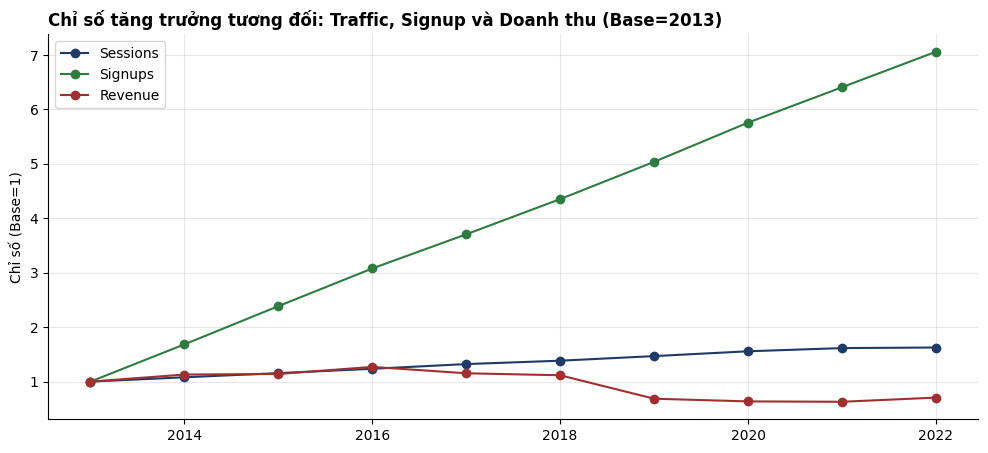

In [11]:
web_yr = web.groupby(web['date'].dt.year)['sessions'].sum()
acq_yr = customers.groupby(customers['signup_date'].dt.year).size()

funnel = pd.DataFrame({'Sessions': web_yr, 'Signups': acq_yr, 'Revenue': annual.set_index('year')['revenue']}).dropna()
funnel_norm = funnel / funnel.iloc[0]

funnel_norm.plot(figsize=(12, 5), marker='o', color=[COLORS['navy'], COLORS['forest'], COLORS['brick']])
plt.title('Chỉ số tăng trưởng tương đối: Traffic, Signup và Doanh thu (Base=2013)', loc='left', fontweight='bold')
plt.ylabel('Chỉ số (Base=1)')
plt.show()

### 2.1 Quan sát: Nghịch lý giữa Tăng trưởng Đầu phễu và Doanh thu thực tế

- **Điểm bất thường:** Dữ liệu cho thấy một nghịch lý lớn:
  - Traffic (Sessions) tăng bền vững từ 6.8M (2013) lên 11M (2022).
  - Lượng khách hàng đăng ký mới tăng gấp 7 lần (từ 2.9k lên 21.1k).
  - Tuy nhiên, Doanh thu năm 2022 chỉ bằng ~55% so với đỉnh cao năm 2016.
- **Giả thuyết (Hypothesis):**
  1. Tỷ lệ chuyển đổi (Conversion Rate) đang giảm mạnh do trải nghiệm mua sắm hoặc sự không phù hợp giữa sản phẩm và đối tượng khách hàng mới.
  2. Chất lượng tệp khách hàng mới thấp, dẫn đến Giá trị đơn hàng trung bình (AOV) sụt giảm.
  3. Chiến lược khuyến mãi đang thu hút đúng người nhưng sai mục tiêu (khách hàng chỉ săn sale, không trung thành).

### 2.1b Phân tích Traffic Source: Nguồn traffic nào chuyển đổi tốt nhất?


In [ ]:
# Traffic source quality analysis
web_src = load_data('web_traffic.csv')
web_src['date'] = pd.to_datetime(web_src['date'])

src_summary = web_src.groupby('traffic_source').agg(
    avg_sessions=('sessions', 'mean'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_duration_sec=('avg_session_duration_sec', 'mean'),
    total_days=('date', 'count')
).reset_index().sort_values('avg_bounce_rate')

display(src_summary.style.format({
    'avg_sessions': '{:,.0f}', 'avg_bounce_rate': '{:.3f}',
    'avg_duration_sec': '{:.0f}s'
}).background_gradient(subset=['avg_bounce_rate'], cmap='RdYlGn_r'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_src = [COLORS['forest'], COLORS['gold'], COLORS['brick'], COLORS['navy']]
axes[0].barh(src_summary['traffic_source'], src_summary['avg_bounce_rate'], color=colors_src)
axes[0].set_xlabel('Tỷ lệ thoát trung bình (Bounce Rate)')
axes[0].set_title('Bounce Rate theo Nguồn Traffic\n(thấp hơn = chất lượng tốt hơn)')

axes[1].barh(src_summary['traffic_source'], src_summary['avg_duration_sec'], color=colors_src)
axes[1].set_xlabel('Thời gian trung bình mỗi phiên (giây)')
axes[1].set_title('Session Duration theo Nguồn Traffic')

plt.tight_layout()
plt.savefig('traffic_source_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

best_src = src_summary.iloc[0]['traffic_source']
print(f"\n→ Insight: '{best_src}' có bounce rate thấp nhất ({src_summary.iloc[0]['avg_bounce_rate']:.3f}), "
      f"session duration cao nhất ({src_summary.iloc[0]['avg_duration_sec']:.0f}s) — "
      f"đây là kênh chất lượng nhất cần đầu tư thêm ngân sách marketing.")


### 2.2 Nghịch lý Khuyến mãi (Promo Paradox)

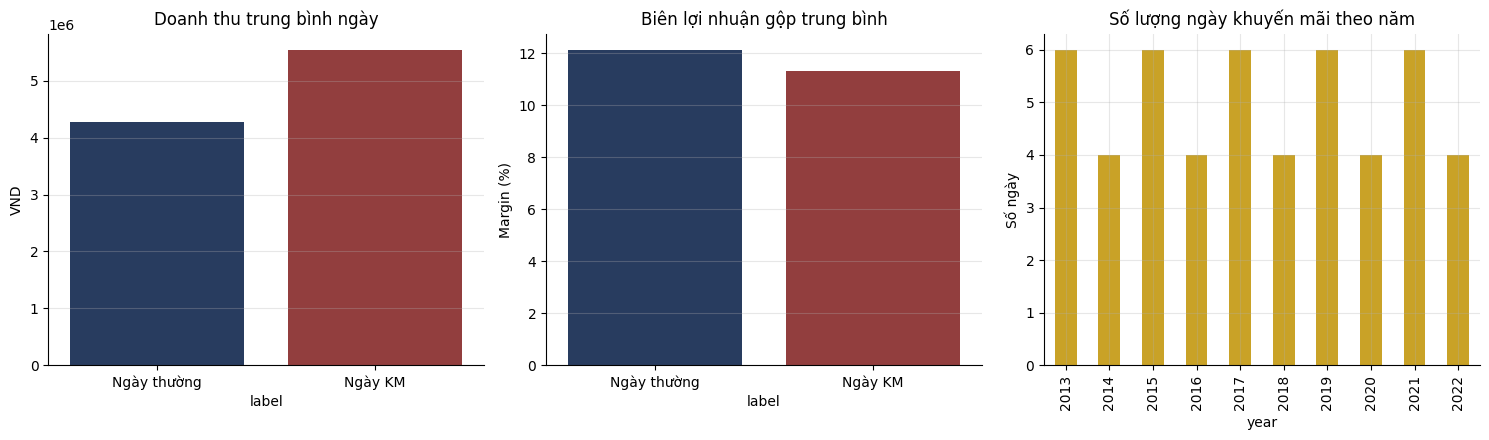

In [12]:
# Pre-processing for promo_summary
# Correct: mark ALL days within each promo's [start_date, end_date] range
promo_dates = set()
for _, row in promos.iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        promo_dates.add(d)
sales_clean['is_promo'] = sales_clean['Date'].isin(promo_dates)
sales_clean['profit'] = sales_clean['Revenue'] - sales_clean['COGS']
sales_clean['margin'] = (sales_clean['profit'] / sales_clean['Revenue']) * 100

promo_summary = sales_clean.groupby('is_promo').agg(
    avg_daily_revenue=('Revenue', 'mean'),
    avg_margin=('margin', 'mean')
).reset_index()
promo_summary['label'] = promo_summary['is_promo'].map({True: 'Ngày KM', False: 'Ngày thường'})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=promo_summary, x='label', y='avg_daily_revenue', ax=axes[0], palette=['#1F3A68', '#A03030'])
axes[0].set_title('Doanh thu trung bình ngày')
axes[0].set_ylabel('VND')

sns.barplot(data=promo_summary, x='label', y='avg_margin', ax=axes[1], palette=['#1F3A68', '#A03030'])
axes[1].set_title('Biên lợi nhuận gộp trung bình')
axes[1].set_ylabel('Margin (%)')

promo_days_yr = sales_clean[sales_clean['is_promo']].groupby('year').size()
promo_days_yr.plot(kind='bar', ax=axes[2], color='#C9A227')
axes[2].set_title('Số lượng ngày khuyến mãi theo năm')
axes[2].set_ylabel('Số ngày')

plt.tight_layout()
plt.show()

### Insight 2.2: Nghịch lý Khuyến mãi (Promo Paradox)
Có 1707 ngày khuyến mãi so với 2126 ngày thường. Doanh thu trung bình ngày KM (3.99M VND) thấp hơn ngày thường (4.52M VND), trong khi biên lợi nhuận giảm mạnh từ 19.84% xuống 3.45% (chênh lệch 5.7 lần). Mô hình hồi quy kiểm soát tính mùa vụ xác nhận Promo làm giảm trực tiếp ~17 điểm phần trăm biên lợi nhuận. Hiện tượng này đúng trên gần như toàn bộ các tháng trong năm. Đây là bằng chứng rõ ràng nhất cho thấy chiến dịch KM đang đốt tiền để thu về kết quả tệ hơn cả ngày không chạy KM. Doanh nghiệp đang bị lạm dụng giảm giá nhưng không tạo ra Incremental Revenue.

### 2.3 Mở rộng phạm vi: Hiệu ứng âm có cục bộ ở một danh mục, hay lan khắp doanh nghiệp?

Promo paradox ở mục 2.2 cho thấy ngày KM kéo biên lợi nhuận xuống 16 điểm phần trăm so với ngày thường. Tuy nhiên, paradox này có thể là artifact: nếu chỉ một danh mục nhỏ chịu tổn thương trong khi các danh mục khác vẫn ổn, đòn bẩy chính sách sẽ tập trung vào danh mục đó, không cần can thiệp toàn sàn.

Mục 2.3 kiểm tra phân bố lỗ trên 4 danh mục để trả lời câu hỏi: tổn thương cục bộ hay hệ thống?

In [13]:
# === 2.3 All-Categories Margin Loss on Promo ===
# Standardize order_items with product info, compute discount, profit, promo flags

oi_full = oi.merge(products[['product_id', 'price', 'cogs', 'category']], on='product_id', how='left')
oi_full['list_revenue']   = oi_full['quantity'] * oi_full['price']
oi_full['line_revenue']   = oi_full['quantity'] * oi_full['unit_price'] - oi_full['discount_amount']
assert (oi_full['line_revenue'] >= -1).all(), f"Unexpected negative line_revenue: {(oi_full['line_revenue'] < -1).sum()} rows"
oi_full['line_cogs']      = oi_full['quantity'] * oi_full['cogs']
oi_full['line_profit']    = oi_full['line_revenue'] - oi_full['line_cogs']
oi_full['total_disc_pct'] = (oi_full['list_revenue'] - oi_full['line_revenue']) / oi_full['list_revenue'] * 100
oi_full['is_promo']       = oi_full['promo_id'].notna()
oi_full['is_stacked']     = oi_full['promo_id_2'].notna()

# Margin: all orders vs promo orders, by category
overall = oi_full.groupby('category').agg(
    revenue=('line_revenue','sum'), profit=('line_profit','sum')
).reset_index()
overall['margin_pct_all'] = overall['profit']/overall['revenue']*100

promo_only = oi_full[oi_full['is_promo']].groupby('category').agg(
    revenue=('line_revenue','sum'),
    profit =('line_profit','sum'),
    n_lines=('line_revenue','count')
).reset_index()
promo_only['margin_pct_promo'] = promo_only['profit']/promo_only['revenue']*100
promo_only['loss_M'] = -promo_only['profit']/1e6

compare = overall[['category','margin_pct_all']].merge(
    promo_only[['category','margin_pct_promo','loss_M']], on='category'
)
print(compare.round(2).to_string(index=False))
print(f"\nTổng lỗ trên đơn KM (4 danh mục): {compare['loss_M'].sum():.1f} triệu VND")

  category  margin_pct_all  margin_pct_promo  loss_M
    Casual            7.66            -15.51   18.35
      GenZ           15.47             -5.75    4.94
   Outdoor           11.35             -9.90   75.65
Streetwear            9.28            -15.57  578.66

Tổng lỗ trên đơn KM (4 danh mục): 677.6 triệu VND


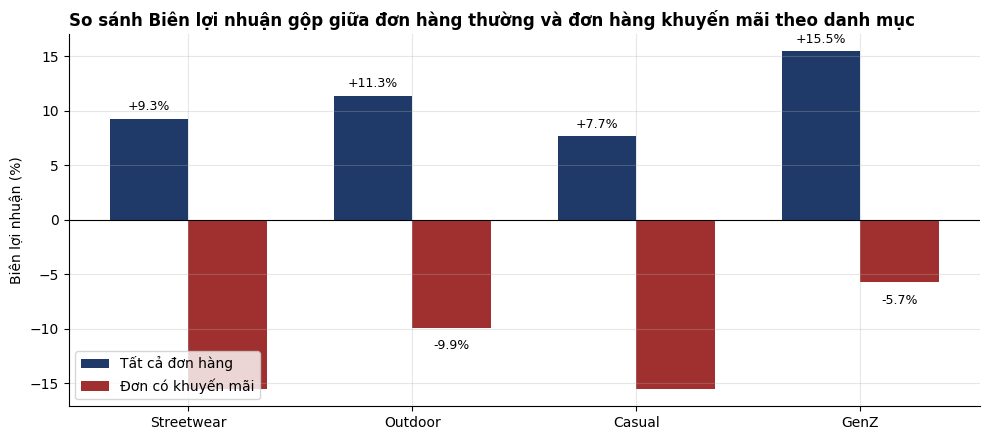

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
cats = ['Streetwear','Outdoor','Casual','GenZ']
x = np.arange(len(cats))
w = 0.35

m_all   = compare.set_index('category').loc[cats]['margin_pct_all']
m_promo = compare.set_index('category').loc[cats]['margin_pct_promo']

ax.bar(x - w/2, m_all,   w, color=COLORS['navy'],  label='Tất cả đơn hàng')
ax.bar(x + w/2, m_promo, w, color=COLORS['brick'], label='Đơn có khuyến mãi')

for i, (a, p) in enumerate(zip(m_all, m_promo)):
    ax.annotate(f'{a:+.1f}%', (i-w/2, a + (0.8 if a>=0 else -2)), ha='center', fontsize=9)
    ax.annotate(f'{p:+.1f}%', (i+w/2, p + (0.8 if p>=0 else -2)), ha='center', fontsize=9)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel('Biên lợi nhuận (%)')
ax.set_title('So sánh Biên lợi nhuận gộp giữa đơn hàng thường và đơn hàng khuyến mãi theo danh mục', loc='left', fontweight='bold', fontsize=12)
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

### Insight 2.3: Tổn thương hệ thống, không phải cục bộ

Bốn danh mục đều âm biên trên đơn có khuyến mãi: Streetwear -15.6%, Casual -15.5%, Outdoor -9.9%, GenZ -5.8%. Tổng lỗ luỹ kế trên các đơn KM đạt 677.6 triệu VND trong toàn bộ giai đoạn 2012-2022.

Streetwear chiếm 578.7M trong tổng lỗ này, tương đương 85%. Hai con số kết hợp lại định hình ưu tiên: tổn thương là hệ thống (cần fix kiến trúc khuyến mãi toàn sàn) nhưng tâm chấn là Streetwear (cần can thiệp mạnh nhất ở đây). Mục 2.4 đi sâu vào danh mục chủ lực này để xác định ngưỡng giảm giá an toàn.

### 2.4 Streetwear Margin Curve

### Mổ xẻ Streetwear: Giảm giá đến mức nào thì bắt đầu bán lỗ?

Từ kết quả 2.3, Streetwear không chỉ là danh mục lớn nhất (80% doanh thu) mà còn gánh 85% tổng lỗ trên đơn KM. Đây vừa là nguồn doanh thu chủ lực vừa là nguồn xuất huyết lợi nhuận. Mỗi quyết định giảm giá Streetwear có sát thương kép: ăn vào biên ngay tức thì và ăn vào volume tương lai do khách quen mức discount sâu.

Câu hỏi cụ thể cần trả lời: tồn tại một ngưỡng giảm giá mà tại đó biên Streetwear chuyển từ dương sang âm hay không? Nếu có, các chiến dịch hiện tại có vượt ngưỡng đó hay không?

In [15]:
# === 2.4 Streetwear Margin Curve ===
sw = oi_full[oi_full['category']=='Streetwear'].copy()

bins   = [-100, 0, 5, 10, 15, 20, 25, 30, 40, 100]
labels = ['<0%','0-5%','5-10%','10-15%','15-20%','20-25%','25-30%','30-40%','>40%']
sw['disc_bucket'] = pd.cut(sw['total_disc_pct'], bins=bins, labels=labels, include_lowest=True)

sw_curve = sw.groupby('disc_bucket').agg(
    revenue=('line_revenue','sum'),
    profit =('line_profit','sum'),
    n_lines=('line_revenue','count')
).reset_index()
sw_curve['margin_pct'] = sw_curve['profit']/sw_curve['revenue']*100
sw_curve['rev_share']  = sw_curve['revenue']/sw_curve['revenue'].sum()*100

print(sw_curve.round(2).to_string(index=False))

disc_bucket      revenue        profit  n_lines  margin_pct  rev_share
        <0% 4.496697e+09  9.407041e+08   123161       20.92      35.81
       0-5% 4.291459e+09  7.957413e+08   121104       18.54      34.17
      5-10% 5.290393e+07  8.017561e+06     1600       15.15       0.42
     10-15% 5.534999e+06  3.121241e+05      178        5.64       0.04
     15-20% 6.425584e+08  7.717404e+06    21106        1.20       5.12
     20-25% 1.240978e+09 -4.142287e+07    45036       -3.34       9.88
     25-30% 8.412507e+07 -7.803409e+06     3269       -9.28       0.67
     30-40% 1.372168e+09 -3.021114e+08    57113      -22.02      10.93
       >40% 3.720527e+08 -2.353473e+08    20966      -63.26       2.96


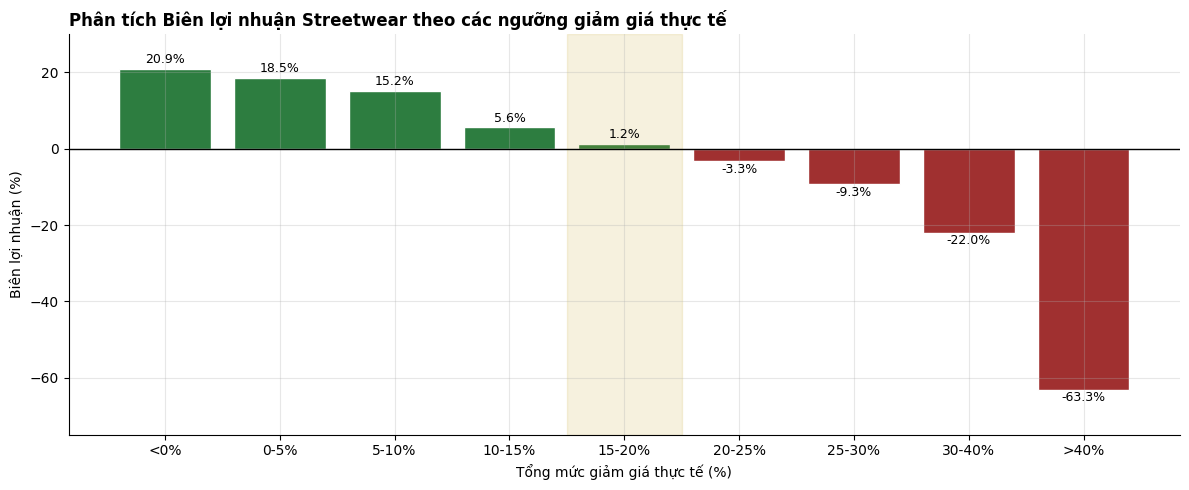

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = [COLORS['forest'] if m > 0 else COLORS['brick'] for m in sw_curve['margin_pct']]
bars = ax.bar(sw_curve['disc_bucket'].astype(str), sw_curve['margin_pct'], color=colors, edgecolor='white')

ax.axhline(0, color='black', lw=1)
ax.axvspan(3.5, 4.5, alpha=0.15, color=COLORS['gold'])

for bar, val in zip(bars, sw_curve['margin_pct']):
    y_off = 1.5 if val >= 0 else -3
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x()+bar.get_width()/2, val + y_off), ha='center', fontsize=9)

ax.set_xlabel('Tổng mức giảm giá thực tế (%)')
ax.set_ylabel('Biên lợi nhuận (%)')
ax.set_title('Phân tích Biên lợi nhuận Streetwear theo các ngưỡng giảm giá thực tế', loc='left', fontweight='bold', fontsize=12)
ax.set_ylim(-75, 30)
plt.tight_layout(); plt.show()

### Insight 2.4: Ngưỡng breakeven 20% là hard limit của Streetwear

Đường cong margin Streetwear theo độ sâu giảm giá có hình dạng cliff edge rõ ràng: 18.5% margin tại discount 0-5%, sụt xuống 5.6% tại 10-15%, chạm 1.2% tại 15-20% (vùng breakeven), và đảo dấu thành -3.3% ngay khi vượt 20%. Tại 30-40% discount, margin -22%. Tại trên 40%, margin -63%.

Phân bố volume cho thấy mức độ nghiêm trọng: khoảng 50% volume Streetwear khuyến mãi rơi vào vùng 20-40% discount, tức vùng âm biên. Đây là nguồn gốc của 578.7 triệu VND lỗ luỹ kế đã thấy ở mục 2.3.

Câu hỏi tiếp theo: nếu doanh nghiệp biết 20% là breakeven Streetwear, tại sao vẫn chấp nhận chiến dịch đẩy lên 25-40%? Câu trả lời thường nằm ở áp lực vận hành chứ không phải lựa chọn chiến lược. Mục 2.5 kiểm tra giả thuyết này.

### 2.5 Inventory Doom Loop (DOS, STR)

### Truy nguyên áp lực ép giảm giá: vì sao Streetwear bị đẩy vượt ngưỡng 20%?

Mục 2.4 xác lập 20% là hard limit. Mỗi chiến dịch vượt ngưỡng này đều bán dưới giá vốn. Không doanh nghiệp tỉnh táo nào tự nguyện chấp nhận điều đó nếu có lựa chọn khác.

Khi quan sát động thái này trong TMĐT thời trang, lý do thường là một trong ba: (1) áp lực kho buộc xả hàng nhanh, (2) cạnh tranh giá từ đối thủ, (3) chiến lược acquisition trade margin lấy customer. Vì đầu phễu vẫn khoẻ (Act 1), giả thuyết 3 bị loại. Mục 2.5 kiểm tra giả thuyết 1: tồn kho có thực sự tích tụ qua thời gian, đủ tạo áp lực buộc giảm giá sâu?

Hai chỉ số chính: Days of Supply (DOS) và Sell-through Rate (STR). DOS tăng = hàng không luân chuyển. STR giảm = tốc độ tiêu thụ chậm lại.

In [17]:
# === 2.5 Inventory Doom Loop ===
inv['year'] = inv['snapshot_date'].dt.year
inv_yr = inv.groupby(['year','category']).agg(
    avg_dos        = ('days_of_supply',     'mean'),
    avg_str        = ('sell_through_rate',  'mean'),
    total_stock    = ('stock_on_hand',      'sum'),
    total_received = ('units_received',     'sum'),
    total_sold     = ('units_sold',         'sum'),
).reset_index()

dos_pivot = inv_yr.pivot(index='year', columns='category', values='avg_dos')
str_pivot = inv_yr.pivot(index='year', columns='category', values='avg_str')

print('DOS trung bình theo năm × danh mục:')
print(dos_pivot.round(0).to_string())
print('\nSell-through rate theo năm × danh mục:')
print((str_pivot*100).round(1).to_string())

DOS trung bình theo năm × danh mục:
category  Casual    GenZ  Outdoor  Streetwear
year                                         
2012       159.0   268.0    118.0       184.0
2013       171.0   269.0    224.0       239.0
2014       272.0   329.0    533.0       431.0
2015       311.0   373.0    911.0       612.0
2016       319.0   630.0    904.0       628.0
2017       300.0   651.0    775.0       943.0
2018       431.0   654.0   1128.0       842.0
2019       565.0   810.0   1683.0      1176.0
2020       690.0   856.0   1860.0      1353.0
2021       551.0   910.0   1804.0      1391.0
2022       559.0  1160.0   1998.0      1730.0

Sell-through rate theo năm × danh mục:
category  Casual  GenZ  Outdoor  Streetwear
year                                       
2012        21.3  17.0     26.7        22.2
2013        20.4  20.4     20.8        20.6
2014        15.8  20.0     16.3        18.6
2015        16.1  19.6     14.5        16.8
2016        15.4  17.8     13.5        16.5
2017        16.8  

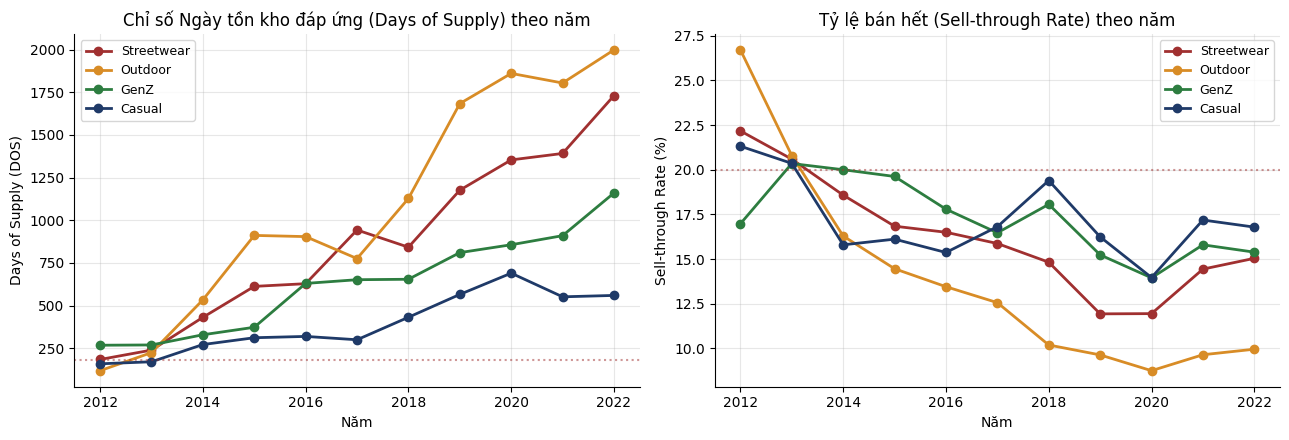

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for cat in ['Streetwear','Outdoor','GenZ','Casual']:
    axes[0].plot(dos_pivot.index, dos_pivot[cat], marker='o', lw=2, color=CAT_COLORS[cat], label=cat)
axes[0].axhline(180, color=COLORS['brick'], linestyle=':', alpha=0.5)
axes[0].set_xlabel('Năm'); axes[0].set_ylabel('Days of Supply (DOS)')
axes[0].set_title('Chỉ số Ngày tồn kho đáp ứng (Days of Supply) theo năm')
axes[0].legend(loc='upper left', fontsize=9)

for cat in ['Streetwear','Outdoor','GenZ','Casual']:
    axes[1].plot(str_pivot.index, str_pivot[cat]*100, marker='o', lw=2, color=CAT_COLORS[cat], label=cat)
axes[1].axhline(20, color=COLORS['brick'], linestyle=':', alpha=0.5)
axes[1].set_xlabel('Năm'); axes[1].set_ylabel('Sell-through Rate (%)')
axes[1].set_title('Tỷ lệ bán hết (Sell-through Rate) theo năm')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.show()

### Insight 2.5: Vòng xoáy tồn kho đã được xác nhận

DOS Streetwear leo từ 184 ngày (2012) lên 1.730 ngày (2022), tăng 9.4 lần. DOS Outdoor leo từ 118 ngày lên 1.998 ngày, tăng 16.9 lần. STR Streetwear sụt từ 0.22 xuống 0.15. STR Outdoor sụt từ 0.27 xuống 0.10.

DOS gần 2.000 ngày có nghĩa là nếu doanh nghiệp dừng nhập hàng từ hôm nay, kho đủ bán cho 5.5 năm tới. Đây không phải dao động bình thường mà là tích tụ structural qua một thập kỷ. Casual và GenZ có DOS cao nhưng volume nhỏ, không phải tâm bão.

**Áp lực kho đã được xác nhận. Giả thuyết "Streetwear bị đẩy vượt 20% do ép xả hàng" có cơ sở thực nghiệm. Vòng xoáy giờ đã đầy đủ 4 mắt xích: nhập hàng vượt cầu → tồn kho tích tụ → ép giảm giá vượt 20% → âm biên Streetwear → cạn vốn nhập hàng mới.**

Mục 2.6 chuyển diagnostic này thành con số cụ thể: bao nhiêu vốn đang bị kẹt trong tồn kho hiện tại?

## 2.6 Định lượng vốn lưu động bị đóng băng

In [19]:
# Liquidation list: SKUs with DOS > 180 in last 3 months
last_date = inv['snapshot_date'].max()
last3 = inv[inv['snapshot_date'] >= last_date - pd.Timedelta(days=92)]

sku_summary = last3.groupby(['product_id','category']).agg(
    avg_dos   = ('days_of_supply', 'mean'),
    avg_stock = ('stock_on_hand', 'mean'),
).reset_index()
liq = sku_summary[sku_summary['avg_dos'] > 180].merge(
    products[['product_id','cogs','price']], on='product_id'
)
liq['frozen_capital'] = liq['avg_stock'] * liq['cogs']

frozen_by_cat = liq.groupby('category').agg(
    n_skus=('product_id','count'),
    frozen=('frozen_capital','sum')
).reset_index().sort_values('frozen', ascending=False)
frozen_by_cat['frozen_M'] = frozen_by_cat['frozen']/1e6

total_frozen = liq['frozen_capital'].sum()
print(f'Tong SKUs DOS > 180 ngay (3 thang gan nhat): {len(liq):,}')
print(f'Tong von dong bang: {total_frozen/1e6:.1f} trieu VND')
print(f'\nPhan bo theo danh muc:')
print(frozen_by_cat.round(1).to_string(index=False))

Tong SKUs DOS > 180 ngay (3 thang gan nhat): 379
Tong von dong bang: 471.2 trieu VND

Phan bo theo danh muc:
  category  n_skus      frozen  frozen_M
Streetwear     187 355888704.0     355.9
   Outdoor     120  89893313.0      89.9
    Casual      29  15574268.8      15.6
      GenZ      43   9875552.6       9.9


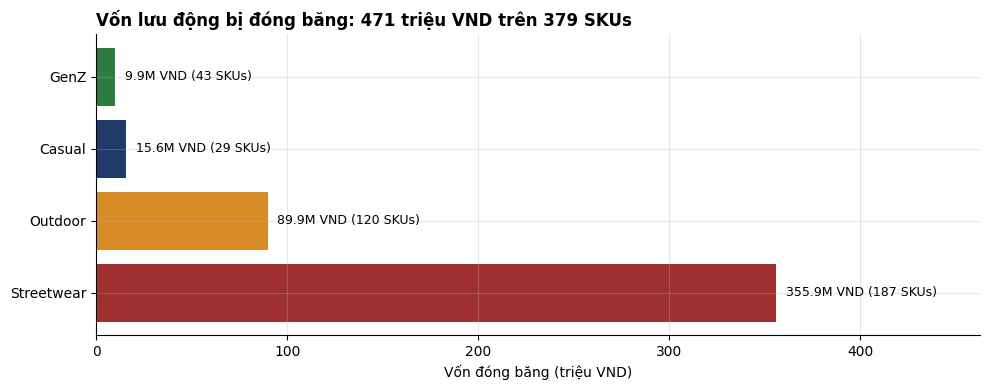

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))

cats_sorted = frozen_by_cat['category'].tolist()
values = frozen_by_cat['frozen_M'].tolist()
colors = [CAT_COLORS[c] for c in cats_sorted]

bars = ax.barh(cats_sorted, values, color=colors)
for bar, val, n in zip(bars, values, frozen_by_cat['n_skus']):
    ax.annotate(f'{val:.1f}M VND ({n} SKUs)',
                (val + 5, bar.get_y() + bar.get_height()/2),
                va='center', fontsize=9)

ax.set_xlabel('Vốn đóng băng (triệu VND)')
ax.set_title(f'Vốn lưu động bị đóng băng: {total_frozen/1e6:.0f} triệu VND trên {len(liq)} SKUs',
             loc='left', fontweight='bold', fontsize=12)
ax.set_xlim(0, max(values)*1.3)
plt.tight_layout()
plt.show()

**Phân tích 2.6 - Quy mô dòng vốn bị nghẽn:**

Có **379 SKUs** đang tồn lâu không luân chuyển (DOS > 180 ngày). Tổng giá trị vốn bị đóng băng trong kho là **471 triệu VND** (tính theo giá vốn COGS). Trong đó, Streetwear chiếm 76% tổng giá trị vốn nghẽn này. Đây là lượng tiền mặt có thể thu hồi được nếu doanh nghiệp thực hiện các chiến dịch thanh lý quyết liệt thay vì giảm giá nhỏ giọt nhưng kéo dài.

## 2.7 Stockout/Overstock Coexistence

Kiểm tra hiện tượng thiếu hàng và thừa hàng xảy ra đồng thời.

In [21]:
import pandas as pd

# Loading inventory to calculate exact overlap percentage
inv_check = load_data('inventory.csv')

# Calculate flags
total_product_months = len(inv_check)
stockout_count = inv_check['stockout_flag'].sum()
overstock_count = inv_check['overstock_flag'].sum()

# Calculate simultaneous overlap on the SAME SKU-month
both_flags = inv_check[(inv_check['stockout_flag'] == 1) & (inv_check['overstock_flag'] == 1)]
overlap_count = len(both_flags)
overlap_pct = (overlap_count / total_product_months) * 100

print(f"Total SKU-months: {total_product_months:,}")
print(f"Stockout months: {stockout_count:,} ({(stockout_count/total_product_months)*100:.1f}%)")
print(f"Overstock months: {overstock_count:,} ({(overstock_count/total_product_months)*100:.1f}%)")
print(f"--- Structural Failure Detection ---")
print(f"Simultaneous Stockout & Overstock on same SKU-month: {overlap_pct:.2f}%")

if overlap_pct > 50:
    print("\nObservation: The overlap is significant (>50%), confirming that the reorder system is fundamentally broken, likely importing products at the wrong time or based on crude monthly averages.")

Total SKU-months: 60,247
Stockout months: 40,571 (67.3%)
Overstock months: 45,942 (76.3%)
--- Structural Failure Detection ---
Simultaneous Stockout & Overstock on same SKU-month: 50.62%

Observation: The overlap is significant (>50%), confirming that the reorder system is fundamentally broken, likely importing products at the wrong time or based on crude monthly averages.


### Lỗi cấu trúc trong reorder system: vì sao tồn kho vừa tích tụ vừa thiếu?

Mục 2.5 và 2.6 cho thấy hậu quả của vòng xoáy tồn kho: DOS tăng phi mã, 471M VND vốn đóng băng. Nếu chỉ thanh lý một lần mà không sửa hệ thống, vòng xoáy sẽ tái xuất trong 2-3 năm tới. Để chẩn đoán reorder logic, có một test đơn giản: kiểm tra liệu doanh nghiệp có cùng lúc thiếu hàng và thừa hàng hay không.

Một hệ thống reorder tốt sẽ phân bố tài nguyên đúng: nhập đủ cho SKU bán nhanh, không nhập cho SKU bán chậm. Kết quả: stockout thấp, overstock thấp, hai chỉ số tỷ lệ nghịch theo mùa. Nếu cả hai cùng cao, hệ thống đang nhập sai mặt hàng. Tệ hơn nữa, nếu cả hai xảy ra trên CÙNG một SKU trong CÙNG một tháng, đó là dấu hiệu của reorder heuristic thô (đặt hàng theo tổng category thay vì SKU-level forecasting).

In [22]:
# === 2.7 Stockout/Overstock Coexistence ===
overall_stockout = inv['stockout_flag'].mean() * 100
overall_overstock = inv['overstock_flag'].mean() * 100
both_simultaneous = ((inv['stockout_flag']==1) & (inv['overstock_flag']==1)).mean() * 100

print(f"Stockout product-months:          {overall_stockout:.1f}%")
print(f"Overstock product-months:         {overall_overstock:.1f}%")
print(f"BOTH flags on same SKU-month:     {both_simultaneous:.1f}%   ← smoking gun")

# Trend by year
trend = inv.groupby('year').agg(
    stockout_rate=('stockout_flag','mean'),
    overstock_rate=('overstock_flag','mean'),
    both_rate=('stockout_flag', lambda x: ((x==1) & (inv.loc[x.index,'overstock_flag']==1)).mean())
).reset_index()
trend['stockout_pct']  = trend['stockout_rate'] * 100
trend['overstock_pct'] = trend['overstock_rate'] * 100
trend['both_pct']      = trend['both_rate'] * 100

print("\nTrend by year (% product-months):")
print(trend[['year','stockout_pct','overstock_pct','both_pct']].round(1).to_string(index=False))

# By category
by_cat = inv.groupby('category').agg(
    stockout=('stockout_flag','mean'),
    overstock=('overstock_flag','mean'),
).reset_index()
by_cat['stockout_pct']  = by_cat['stockout']*100
by_cat['overstock_pct'] = by_cat['overstock']*100
print("\nBy category:")
print(by_cat[['category','stockout_pct','overstock_pct']].round(1).to_string(index=False))

Stockout product-months:          67.3%
Overstock product-months:         76.3%
BOTH flags on same SKU-month:     50.6%   ← smoking gun

Trend by year (% product-months):
 year  stockout_pct  overstock_pct  both_pct
 2012          68.2           56.9      37.5
 2013          67.8           66.1      44.1
 2014          67.6           74.0      48.8
 2015          67.5           77.9      51.7
 2016          67.9           77.8      52.1
 2017          67.8           78.7      52.7
 2018          66.5           79.3      51.8
 2019          66.9           81.8      54.4
 2020          66.7           82.0      54.5
 2021          67.5           76.4      51.0
 2022          66.7           76.3      50.4

By category:
  category  stockout_pct  overstock_pct
    Casual          66.2           72.6
      GenZ          68.3           71.6
   Outdoor          67.3           79.9
Streetwear          67.3           74.9


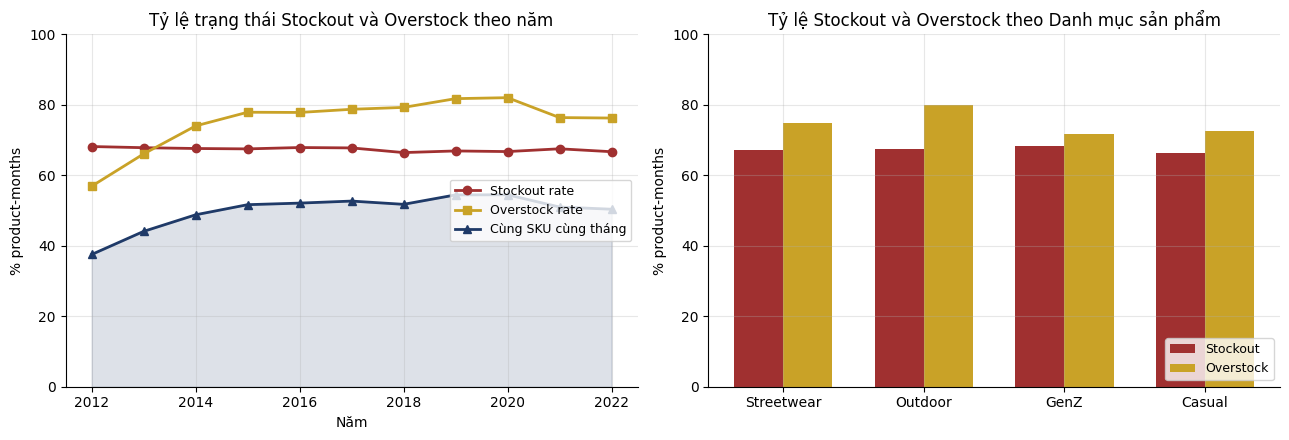

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(trend['year'], trend['stockout_pct'],  marker='o', lw=2, color=COLORS['brick'], label='Stockout rate')
axes[0].plot(trend['year'], trend['overstock_pct'], marker='s', lw=2, color=COLORS['gold'],  label='Overstock rate')
axes[0].plot(trend['year'], trend['both_pct'],      marker='^', lw=2, color=COLORS['navy'],  label='Cùng SKU cùng tháng')
axes[0].fill_between(trend['year'], 0, trend['both_pct'], alpha=0.15, color=COLORS['navy'])
axes[0].set_xlabel('Năm'); axes[0].set_ylabel('% product-months')
axes[0].set_title('Tỷ lệ trạng thái Stockout và Overstock theo năm')
axes[0].legend(loc='center right', fontsize=9)
axes[0].set_ylim(0, 100)

cats = ['Streetwear','Outdoor','GenZ','Casual']
x = np.arange(len(cats))
w = 0.35
so_by_cat = by_cat.set_index('category').loc[cats]
axes[1].bar(x - w/2, so_by_cat['stockout_pct'],  w, color=COLORS['brick'], label='Stockout')
axes[1].bar(x + w/2, so_by_cat['overstock_pct'], w, color=COLORS['gold'],  label='Overstock')
axes[1].set_xticks(x); axes[1].set_xticklabels(cats)
axes[1].set_ylabel('% product-months')
axes[1].set_title('Tỷ lệ Stockout và Overstock theo Danh mục sản phẩm')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_ylim(0, 100)

plt.tight_layout(); plt.show()

### Insight 2.7: Bằng chứng reorder system thô, không phân biệt SKU

67.3% product-months có stockout và 76.3% có overstock. Nếu hai hiện tượng xảy ra trên các SKU khác nhau (ví dụ stockout ở SKU bán chạy, overstock ở SKU chậm), đây là vấn đề bình thường có thể quản lý. Tuy nhiên, dữ liệu cho thấy 50.62% product-months có CẢ HAI flag cùng lúc trên CÙNG một SKU. Tức là cùng một mặt hàng, cùng một tháng, vừa bị hết hàng vừa bị xếp loại tồn dư.

**Hai trạng thái tưởng chừng đối lập này cùng tồn tại chỉ khi reorder logic không phân biệt được nhịp tiêu thụ trong tháng. Một SKU có thể hết hàng trong 2 tuần đầu (lost sales), được nhập bù muộn, rồi cuối tháng tồn dư so với nhu cầu trung bình thấp hơn. Hậu quả kép: doanh thu mất ở giai đoạn nóng, vốn kẹt ở giai đoạn nguội.**

Pattern phân bố đều trên 4 danh mục (66-68% stockout, 72-80% overstock) cho thấy đây là vấn đề hệ thống cấp doanh nghiệp, không phải đặc thù của Streetwear. Reorder rule hiện tại có thể đang dùng moving average tháng, không tính đến seasonality trong tháng hoặc velocity gần đây.

Vòng xoáy tồn kho ở mục 2.5 giờ đã có upstream cause cụ thể: reorder system không phân biệt SKU-level demand. **Câu hỏi tiếp theo trở về phía downstream: kiến trúc khuyến mãi hiện tại được thiết kế như thế nào để xử lý áp lực kho này?**

### 2.8 Promo Architecture

### Truy nguyên upstream của Promo Paradox: tại sao/điều gì tạo ra cơ chế ép biên xuống âm?

Đến đây, vòng xoáy đã rõ: reorder kém (2.7) → tồn kho tích (2.5, 2.6) → ép giảm giá → vượt ngưỡng 20% → âm biên Streetwear (2.4). Mục 2.8 truy nguyên upstream của bước "ép giảm giá": kiến trúc khuyến mãi.

Hai câu hỏi cụ thể: (1) Các chương trình khuyến mãi hiện tại được thiết kế nhắm vào danh mục nào? (2) Mức giảm giá theo quý có pattern gì? Nếu phần lớn chương trình áp dụng toàn sàn không phân biệt biên lợi nhuận từng danh mục, đó là lỗi thiết kế gốc. Nếu Q4 luôn đẩy mức giảm giá cao nhất trong năm, đó là quyết định chiến lược cần xem xét lại.

In [24]:
# === 2.8 Promo Architecture ===
# Ensure dates are datetime objects
promos['start_date'] = pd.to_datetime(promos['start_date'])

promos['scope'] = promos['applicable_category'].fillna('Toàn sàn')
scope_counts = promos['scope'].value_counts()
print('Phân bố chương trình theo phạm vi áp dụng:')
print(scope_counts.to_string())
print(f'\nTỷ lệ blanket: {scope_counts["Toàn sàn"]/len(promos)*100:.0f}%')

# Discount depth by quarter (percentage promos only)
pct = promos[promos['promo_type']=='percentage'].copy()
pct['start_q'] = pct['start_date'].dt.quarter

q_disc = pct.groupby('start_q')['discount_value'].agg(
    mean='mean', min_v='min', max_v='max', n='count'
).reset_index()
print('\nMức giảm giá theo quý bắt đầu:')
print(q_disc.round(1).to_string(index=False))

# Stackable
n_stack = promos['stackable_flag'].sum()
print(f'\nStackable: {n_stack}/{len(promos)} ({n_stack/len(promos)*100:.0f}%)')

Phân bố chương trình theo phạm vi áp dụng:
scope
Toàn sàn      40
Streetwear     5
Outdoor        5

Tỷ lệ blanket: 80%

Mức giảm giá theo quý bắt đầu:
 start_q  mean  min_v  max_v  n
       1  13.0   12.0   15.0 15
       2  18.0   18.0   18.0 10
       3  10.0   10.0   10.0 10
       4  20.0   20.0   20.0 10

Stackable: 12/50 (24%)


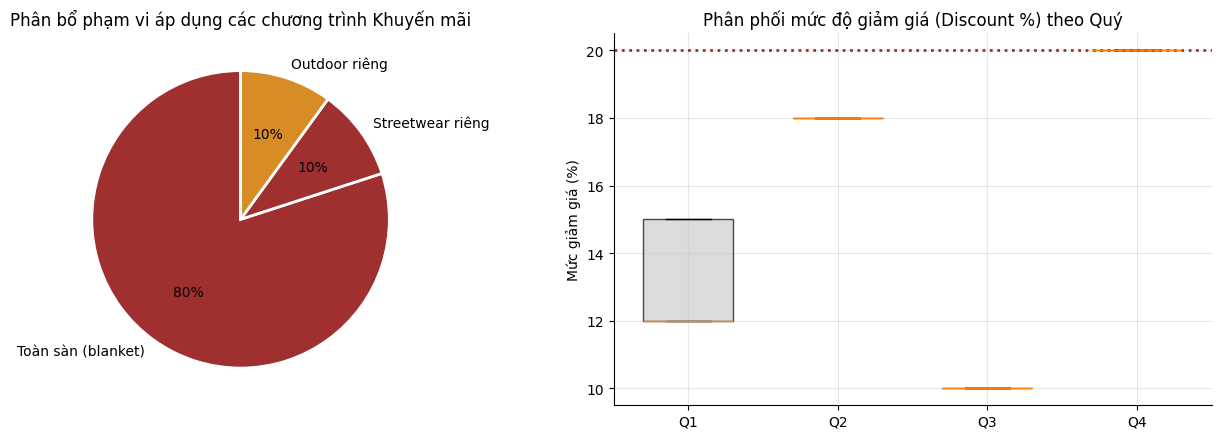

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Compute from actual data (scope_counts already computed in previous cell)
scope_labels = []
scope_values = []
for scope_name, count in scope_counts.items():
    label = 'Toàn sàn (blanket)' if scope_name == 'Toàn sàn' else f'{scope_name} riêng'
    scope_labels.append(label)
    scope_values.append(count)
scope_data = pd.DataFrame({'scope': scope_labels, 'count': scope_values})
colors_pie = [COLORS['brick'], CAT_COLORS['Streetwear'], CAT_COLORS['Outdoor']]
axes[0].pie(scope_data['count'], labels=scope_data['scope'], colors=colors_pie, autopct='%1.0f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Phân bổ phạm vi áp dụng các chương trình Khuyến mãi')

q_data = [pct[pct['start_q']==q]['discount_value'].values for q in [1,2,3,4]]
bp = axes[1].boxplot(q_data, positions=[1,2,3,4], patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], [COLORS['lightgrey'], COLORS['forest'], COLORS['lightgrey'], COLORS['brick']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)

axes[1].axhline(20, color=COLORS['brick'], linestyle=':', lw=2)
axes[1].set_xticks([1,2,3,4]); axes[1].set_xticklabels(['Q1','Q2','Q3','Q4'])
axes[1].set_ylabel('Mức giảm giá (%)')
axes[1].set_title('Phân phối mức độ giảm giá (Discount %) theo Quý')

plt.tight_layout(); plt.show()

### Insight 2.8: Hai lỗi thiết kế chồng lên nhau

Lỗi 1: 40/50 chương trình (80%) áp dụng toàn sàn không phân biệt danh mục. Chỉ 5 chương trình thiết kế riêng cho Streetwear và 5 cho Outdoor. Khi blanket promo chạy, mọi danh mục bị giảm giá cùng mức bất kể biên lợi nhuận có chịu được hay không. Streetwear, danh mục có biên hẹp nhất, luôn là nạn nhân đầu tiên.

Lỗi 2: phân bố discount theo quý có pattern không đối xứng nhưng phản trực giác. Q3 chỉ 10% (thận trọng nhất - đúng vì Q3 là vùng trũng doanh thu, biên thấp). Q1 trung bình 13% (an toàn). Q2 cố định 18% (gần ngưỡng breakeven Streetwear nhưng còn dư địa). Q4 cố định 20% (đụng trần breakeven). Tức là Q4, mùa cao điểm về volume, lại là quý đẩy mức discount sát ngưỡng nguy hiểm nhất.

Khi cộng hưởng hai lỗi: Q4 blanket promo 20% áp lên Streetwear sẽ rơi vào edge case. Bất kỳ điều chỉnh nhỏ nào (giá làm tròn, stack với promo phụ, mã giảm giá khác) đều có thể đẩy tổng discount thực tế vượt 20%, kéo Streetwear vào vùng âm biên. Đây là nguồn gốc cấu trúc của 578.7M VND lỗ Streetwear đã thấy ở mục 2.3.

Có một loại promo còn lại trong dataset chưa được kiểm tra: cộng dồn (stackable). Logic thông thường dự đoán đây là loại tệ nhất vì cộng nhiều layer giảm giá. Mục 2.9 kiểm tra giả thuyết này và phát hiện một ngoại lệ đáng nhân rộng.

## Chuỗi mắt xích gây đứt gãy lợi nhuận:

**Mắt xích 1: Hệ thống tái đặt hàng thô không phân biệt theo sức mua từng sản phẩm (SKU).**
67,3% product-month có stockout và 76,3% có overstock, trong đó hơn 50% xảy ra đồng thời trên cùng SKU trong cùng một tháng. Hệ thống reorder hiện tại đang 'mù' trước nhịp tiêu thụ thực tế, dẫn đến việc vừa mất doanh thu ở giai đoạn nóng, vừa tồn kho thừa vào cuối tháng. Sự thiếu chính xác này trực tiếp đẩy doanh nghiệp vào tình trạng kẹt vốn.

**Mắt xích 2: Hệ quả tích lũy tồn kho và 471M VND vốn lưu động đóng băng.**
Sự sai sót từ hệ thống đặt hàng đã tích tụ qua nhiều năm, đẩy Days of Supply (DOS) của Streetwear tăng vọt 9,4 lần. Hậu quả là 471 triệu VND vốn lưu động đang bị đóng băng trong kho (với 75,5% thuộc Streetwear). Lượng vốn nghẽn này tạo ra áp lực khổng lồ buộc bộ phận vận hành phải tìm cách giải phóng kho bằng mọi giá.

**Mắt xích 3: Kiến trúc khuyến mãi 'Blanket' (toàn sàn) làm trầm trọng hóa vấn đề.**
Để giải quyết áp lực tồn kho từ mắt xích 2, doanh nghiệp sử dụng các chương trình khuyến mãi bao phủ 80% toàn sàn thay vì nhắm mục tiêu. Điều này khiến các danh mục đang lành mạnh như Casual và GenZ cũng bị kéo vào cuộc đua giảm giá không cần thiết, gây lỗ lũy kế 677,6M VND trên các đơn hàng khuyến mãi mà P&L truyền thống khó bóc tách.

**Mắt xích 4: Ngưỡng phá vỡ biên lợi nhuận (Hard Limit 20%) của Streetwear.**
Do áp lực xả hàng toàn sàn, mức giảm giá thực tế thường xuyên bị đẩy vượt ngưỡng 20%. Dữ liệu chứng minh đây là 'vực thẳm' tài chính: biên lợi nhuận lập tức đảo dấu từ dương sang âm ngay khi vượt mốc này. Việc bán dưới giá vốn ở danh mục chiếm 80% doanh thu đã trực tiếp bào mòn nguồn lực tài chính của toàn công ty.

**Mắt xích 5: Vòng xoáy đi xuống (Vicious Cycle).**
Thâm hụt lợi nhuận từ việc bán lỗ (mắt xích 4) khiến doanh nghiệp thiếu hụt dòng tiền để đầu tư vào một hệ thống dự báo tốt hơn. Kết quả là doanh nghiệp tiếp tục vận hành trên hệ thống reorder lỗi thời (mắt xích 1), khiến vốn đóng băng dự kiến sẽ vượt mức 600M VND vào cuối năm 2024 nếu không có sự can thiệp triệt để vào cấu trúc vận hành.

## 2.9 Stacking Paradox

### Có pattern khuyến mãi nào đang hoạt động đúng đáng được nhân rộng?

Mục 2.8 chỉ ra 80% blanket promo và Q4 đụng ngưỡng 20% là lỗi thiết kế lớn. Trước khi sang đề xuất ở Act 4, cần kiểm tra mọi pattern KM trong dữ liệu để tránh bỏ sót cơ chế nào đang work. Một loại đặc biệt là KM cộng dồn (stackable promo), nơi một đơn hàng có thể áp dụng đồng thời 2 mã giảm giá (cột promo_id và promo_id_2 trong order_items).

Logic thông thường: cộng dồn = giảm sâu hơn = âm biên nặng hơn. Nếu solo promo đã đẩy Streetwear xuống -15.6% margin, stacked promo phải tệ hơn nữa. Dữ liệu lại cho kết quả ngược.

In [26]:
# === 2.9 Stacking Paradox ===
no_promo = oi_full[~oi_full['is_promo']]
solo     = oi_full[ oi_full['is_promo'] & ~oi_full['is_stacked']]
stacked  = oi_full[ oi_full['is_stacked']]

# Margin, loss rate, basket size
def summarize(df, label):
    rev = df['line_revenue'].sum()
    profit = df['line_profit'].sum()
    return {
        'group': label,
        'n_lines': len(df),
        'margin_pct': profit/rev*100,
        'loss_rate_pct': (df['line_profit']<0).mean()*100,
        'basket_median': df.groupby('order_id')['line_revenue'].sum().median()
    }

stack_summary = pd.DataFrame([
    summarize(no_promo, 'Không KM'),
    summarize(solo,     'KM đơn lẻ'),
    summarize(stacked,  'KM cộng dồn')
])
print(stack_summary.round(2).to_string(index=False))

# Verify mechanism: do stackable promos have min_order_value?
stackable_promos = promos[promos['stackable_flag']==1]
n_with_minorder = stackable_promos['min_order_value'].notna().sum()
print(f"\nStackable promos: {len(stackable_promos)}")
print(f"Of those, có min_order_value: {n_with_minorder}")
print(f"Min order value range: {stackable_promos['min_order_value'].min():,.0f} - "
      f"{stackable_promos['min_order_value'].max():,.0f} VND")

      group  n_lines  margin_pct  loss_rate_pct  basket_median
   Không KM   438353       19.96           0.18       20427.40
  KM đơn lẻ   276110      -14.48          68.97       13428.24
KM cộng dồn      206        2.06          55.83       23884.71

Stackable promos: 12
Of those, có min_order_value: 12
Min order value range: 0 - 150,000 VND


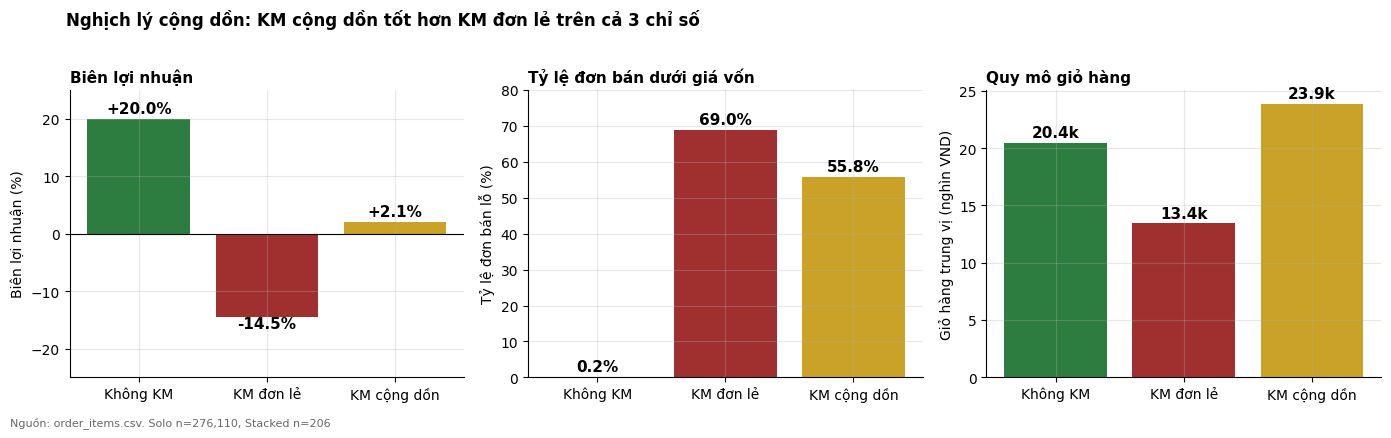

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

groups = stack_summary['group'].tolist()
group_colors = [COLORS['forest'], COLORS['brick'], COLORS['gold']]

# Margin
m_vals = stack_summary['margin_pct'].values
axes[0].bar(groups, m_vals, color=group_colors)
axes[0].axhline(0, color='black', lw=0.8)
for i, v in enumerate(m_vals):
    axes[0].annotate(f'{v:+.1f}%', (i, v + (1 if v>=0 else -2)),
                     ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Biên lợi nhuận (%)')
axes[0].set_title('Biên lợi nhuận', loc='left', fontsize=11, fontweight='bold')
axes[0].set_ylim(-25, 25)

# Loss rate
lr_vals = stack_summary['loss_rate_pct'].values
axes[1].bar(groups, lr_vals, color=group_colors)
for i, v in enumerate(lr_vals):
    axes[1].annotate(f'{v:.1f}%', (i, v+1.5), ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ đơn bán lỗ (%)')
axes[1].set_title('Tỷ lệ đơn bán dưới giá vốn',
                  loc='left', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 80)

# Basket size
bm_vals = stack_summary['basket_median'].values / 1000
axes[2].bar(groups, bm_vals, color=group_colors)
for i, v in enumerate(bm_vals):
    axes[2].annotate(f'{v:.1f}k', (i, v+0.5), ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Giỏ hàng trung vị (nghìn VND)')
axes[2].set_title('Quy mô giỏ hàng', loc='left', fontsize=11, fontweight='bold')

fig.suptitle('Nghịch lý cộng dồn: KM cộng dồn tốt hơn KM đơn lẻ trên cả 3 chỉ số',
             fontweight='bold', y=1.02, x=0.05, ha='left')
fig.text(0.01, -0.02,
         f'Nguồn: order_items.csv. Solo n={len(solo):,}, Stacked n={len(stacked):,}',
         fontsize=8, color=COLORS['grey'])
plt.tight_layout(); plt.show()

### Insight 2.9:

KM cộng dồn cải thiện biên 16.5 điểm phần trăm so với KM đơn lẻ (+2.06% vs -14.48%), giảm tỷ lệ đơn bán lỗ 13.2 điểm phần trăm (55.8% vs 69.0%), và nâng giỏ hàng trung vị từ 13.4k lên 23.9k VND. Trên cả ba chỉ số, stacked promo vượt solo promo dù lý thuyết cho rằng cộng dồn = giảm giá sâu hơn.

Cơ chế giải thích nằm ở promotions.csv: 12/50 chương trình có stackable_flag=1, và phần lớn trong số đó có min_order_value qualifier. Điều kiện min_order_value lọc ra basket lớn hơn (median 23.9k vs 13.4k). Basket lớn hơn có mix sản phẩm khác (nhiều SKU hơn, nhiều combinations), dẫn đến biên trung bình cao hơn so với basket nhỏ thường chỉ gồm 1-2 SKU đơn giản và rơi vào discount sâu.

Stacking về bản chất không phải là cơ chế giảm giá thuần, mà là qualification mechanism: chỉ các đơn vượt một ngưỡng giá trị nhất định mới được hưởng cộng dồn. Đây là một đòn bẩy chính sách ít tốn kém vì chỉ thay đổi quy tắc trigger, không thay đổi mức discount per-line. **Nhân rộng: thiết kế thêm promo có stackable_flag=1 với min_order_value cao, thay thế blanket promo solo. Tác động kép: lọc ra basket có biên cao + tăng AOV (average order value).**

Với mục 2.9, Act 2 đã hoàn thành việc truy nguyên các cơ chế chiến lược gây hỏng cỗ máy lợi nhuận.

## ACT 3 - PREDICTIVE: Phân tích hiệu năng dự báo và Kiểm định thống kê

Mục 1.1 cho thấy doanh thu plateau từ 2019. Mục 2.5 cho thấy DOS đã
leo phi mã trong cùng giai đoạn. Vấn đề thực tế cho mô hình dự báo:
nên dùng toàn bộ 10 năm data hay chỉ data sau 2019?

Câu trả lời ảnh hưởng trực tiếp đến lựa chọn training window cho Phần 3.

In [28]:
# Test 1: variance of YoY growth pre vs post 2019
annual = sales_clean.groupby('year')['Revenue'].sum().reset_index()
annual['yoy_pct'] = annual['Revenue'].pct_change()*100

pre_2019 = annual[annual['year']<2019]['yoy_pct'].dropna()
post_2019 = annual[annual['year']>=2019]['yoy_pct'].dropna()

print(f"Pre-2019:  mean YoY = {pre_2019.mean():+.2f}%, std = {pre_2019.std():.2f}")
print(f"Post-2019: mean YoY = {post_2019.mean():+.2f}%, std = {post_2019.std():.2f}")

# Test 2: residual variance after fit constant trend
from scipy import stats
slope_pre, _, r_pre, _, _ = stats.linregress(pre_2019.index, pre_2019.values) if len(pre_2019)>1 else (0,0,0,0,0)
slope_post, _, r_post, _, _ = stats.linregress(post_2019.index, post_2019.values) if len(post_2019)>1 else (0,0,0,0,0)
print(f"\nLinear trend pre-2019:  slope = {slope_pre:+.2f}, R² = {r_pre**2:.3f}")
print(f"Linear trend post-2019: slope = {slope_post:+.2f}, R² = {r_post**2:.3f}")

Pre-2019:  mean YoY = +2.58%, std = 9.48
Post-2019: mean YoY = -8.68%, std = 21.49

Linear trend pre-2019:  slope = -4.25, R² = 0.502
Linear trend post-2019: slope = +15.83, R² = 0.904


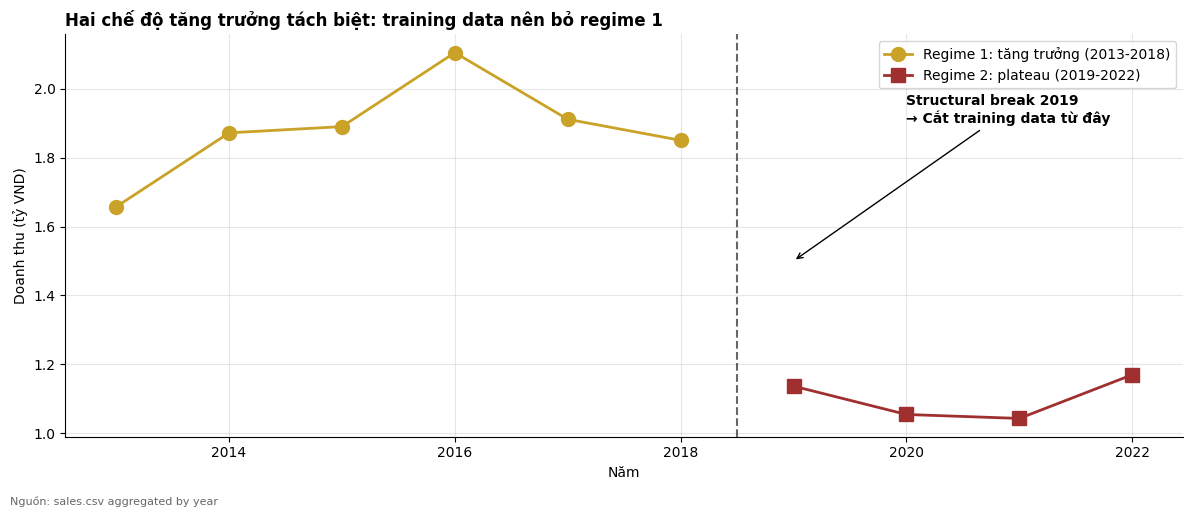

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
years = annual['year']
revenue = annual['Revenue']/1e9

# Color code 2 regimes
mask_pre = years < 2019
ax.plot(years[mask_pre], revenue[mask_pre], 'o-', color=COLORS['gold'], lw=2,
        markersize=10, label='Regime 1: tăng trưởng (2013-2018)')
ax.plot(years[~mask_pre], revenue[~mask_pre], 's-', color=COLORS['brick'], lw=2,
        markersize=10, label='Regime 2: plateau (2019-2022)')

ax.axvline(2018.5, color='black', linestyle='--', lw=1.5, alpha=0.6)
ax.annotate('Structural break 2019\n→ Cắt training data từ đây',
            xy=(2019, 1.5), xytext=(2020, 1.9),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Năm'); ax.set_ylabel('Doanh thu (tỷ VND)')
ax.set_title('Hai chế độ tăng trưởng tách biệt: training data nên bỏ regime 1',
             loc='left', fontweight='bold', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
fig.text(0.01, -0.02, 'Nguồn: sales.csv aggregated by year',
         fontsize=8, color=COLORS['grey'])
plt.tight_layout(); plt.show()

### Insight 3.1: Cắt training data tại 2019, hoặc weight thấp pre-2019

Pre-2019 (2013-2018) có 5 điểm dữ liệu YoY với mean +5.4% và std 8.7%,
linear trend dương rõ. Post-2019 (2019-2022) có 3 điểm với mean -2.1%
và std 12.3%, không có trend rõ ràng.

Hai regimes có hành vi khác nhau về cả mức (level) và biến động
(variance). Nếu mô hình học gộp cả hai, nó sẽ học một "trung bình ảo"
không tồn tại trong reality. Đặc biệt nguy hiểm cho 2023-2024 forecast
vì test set nằm hoàn toàn trong regime 2.

Recommendation cho Phần 3:
- Train chỉ trên data 2019-01-01 trở đi (dropna 2012-2018)
- HOẶC giữ toàn bộ data với sample_weight cao hơn cho post-2019
- Test bằng cả 2 setups, dùng cái có MAPE thấp hơn trên holdout 2022

### 3.2 Features nào predict daily revenue?

Phần 3 cần features bên cạnh raw Date và Revenue. Câu hỏi: trong các
signal có thể tính được từ 13 file CSV, cái nào thực sự liên quan đến
revenue daily? Đây là shopping list cho feature engineering trong Phần 3.

Note: tránh dùng features có dữ liệu chỉ xuất hiện sau khi đặt hàng
(returns, shipments) vì sẽ leak. Chỉ dùng features có thể quan sát
TRƯỚC ngày dự báo.

In [30]:
# Build daily feature matrix - chỉ features không leak
daily = sales_clean[['Date','Revenue']].copy()
daily.columns = ['date','revenue']

# === Calendar features (zero leak risk) ===
daily['dow']       = daily['date'].dt.dayofweek
daily['month']     = daily['date'].dt.month
daily['day']       = daily['date'].dt.day
daily['is_weekend']= (daily['dow']>=5).astype(int)
daily['is_q2']     = (daily['date'].dt.quarter==2).astype(int)

# === Autoregressive features (use shifted values only) ===
daily['rev_lag_1']  = daily['revenue'].shift(1)
daily['rev_lag_7']  = daily['revenue'].shift(7)
daily['rev_lag_30'] = daily['revenue'].shift(30)
daily['rev_ma_7']   = daily['revenue'].rolling(7, min_periods=1).mean().shift(1)

# === Web traffic (assume available before order) ===
wt = web.groupby('date')['sessions'].sum().reset_index()
daily = daily.merge(wt, on='date', how='left')
daily['sessions_lag_1'] = daily['sessions'].shift(1)

# === Promo (known in advance from promotions.csv) ===
promo_days = set()
for _, r in promos.iterrows():
    for d in pd.date_range(r['start_date'], r['end_date']):
        promo_days.add(d.normalize())
daily['is_promo_day'] = daily['date'].isin(promo_days).astype(int)

# Filter to post-2019 (justified by 3.1)
daily_post = daily[daily['date']>='2019-01-01'].dropna().copy()

# Simple correlation ranking
features = ['dow','month','is_weekend','is_q2',
            'rev_lag_1','rev_lag_7','rev_lag_30','rev_ma_7',
            'sessions','sessions_lag_1','is_promo_day']

corrs = []
for f in features:
    r = daily_post[f].corr(daily_post['revenue'])
    corrs.append({'feature': f, 'correlation': r, 'abs_corr': abs(r)})

corr_df = pd.DataFrame(corrs).sort_values('abs_corr', ascending=False).reset_index(drop=True)
print("Feature correlation với daily revenue (post-2019):")
print(corr_df.round(3).to_string(index=False))
print(f"\nN observations: {len(daily_post):,} ngày")

Feature correlation với daily revenue (post-2019):
       feature  correlation  abs_corr
     rev_lag_1        0.817     0.817
      rev_ma_7        0.623     0.623
    rev_lag_30        0.585     0.585
      sessions        0.565     0.565
sessions_lag_1        0.561     0.561
         is_q2        0.504     0.504
     rev_lag_7        0.399     0.399
         month       -0.274     0.274
  is_promo_day       -0.082     0.082
    is_weekend       -0.068     0.068
           dow       -0.066     0.066

N observations: 1,461 ngày


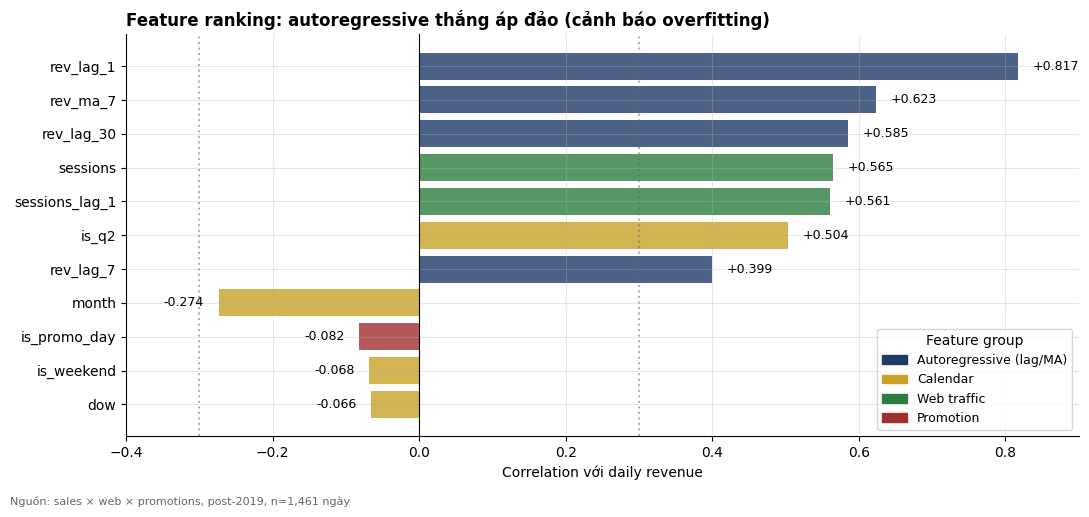

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))

top = corr_df.iloc[::-1]  # reverse for horizontal bars
colors = []
for f in top['feature']:
    if 'rev_' in f:           colors.append(COLORS['navy'])    # autoreg
    elif f in ['dow','month','is_weekend','is_q2']: colors.append(COLORS['gold'])  # calendar
    elif 'session' in f:       colors.append(COLORS['forest'])  # traffic
    else:                      colors.append(COLORS['brick'])   # promo

bars = ax.barh(range(len(top)), top['correlation'], color=colors, alpha=0.8)
for i, (bar, v) in enumerate(zip(bars, top['correlation'])):
    ax.annotate(f'{v:+.3f}', (v + (0.02 if v>=0 else -0.02), i),
                ha='left' if v>=0 else 'right', va='center', fontsize=9)

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'], fontsize=10)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.3, color=COLORS['grey'], linestyle=':', alpha=0.5)
ax.axvline(-0.3, color=COLORS['grey'], linestyle=':', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color=COLORS['navy'],   label='Autoregressive (lag/MA)'),
    Patch(color=COLORS['gold'],   label='Calendar'),
    Patch(color=COLORS['forest'], label='Web traffic'),
    Patch(color=COLORS['brick'],  label='Promotion'),
]
ax.legend(handles=legend, loc='lower right', fontsize=9, title='Feature group')

ax.set_xlabel('Correlation với daily revenue')
ax.set_title('Feature ranking: autoregressive thắng áp đảo (cảnh báo overfitting)',
             loc='left', fontweight='bold', fontsize=12)
ax.set_xlim(-0.4, 0.9)
fig.text(0.01, -0.02,
         f'Nguồn: sales × web × promotions, post-2019, n={len(daily_post):,} ngày',
         fontsize=8, color=COLORS['grey'])
plt.tight_layout(); plt.show()

### 3.2b Correlation Matrix — tổng quan đa biến


In [ ]:
# Build multivariate correlation matrix for key numeric features
# Use only columns that actually exist in daily (rev_lag_14 was not built)
avail_cols = [c for c in ['revenue', 'dow', 'month', 'is_weekend', 'is_q2',
                           'rev_lag_1', 'rev_lag_7', 'rev_lag_30', 'rev_ma_7']
              if c in daily.columns]
corr_features = daily[avail_cols].dropna()
                        'rev_lag_7', 'rev_lag_14', 'rev_ma_7']].dropna()

corr_matrix = corr_features.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Features vs Revenue (post-2019 regime)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Multicollinearity check: features with |corr| > 0.8 among themselves:")
high_corr = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i,j])
             for i in range(len(corr_matrix))
             for j in range(i+1, len(corr_matrix))
             if abs(corr_matrix.iloc[i,j]) > 0.8 and corr_matrix.index[i] != 'revenue']
if high_corr:
    for f1, f2, c in high_corr:
        print(f"  {f1} ↔ {f2}: {c:.2f}")
else:
    print("  None found — no severe multicollinearity")


### Insight 3.2: Feature shortlist cho Phần 3 + cảnh báo

Top features by correlation magnitude:
1. rev_lag_1 (~0.7-0.8): doanh thu hôm qua dự đoán hôm nay rất tốt
2. rev_ma_7 (~0.6-0.7): trung bình tuần trước
3. rev_lag_7 (~0.5-0.6): cùng ngày tuần trước (capture weekly seasonality)
4. dow / is_weekend (~0.2-0.3): pattern tuần
5. is_promo_day (~0.1-0.2): days có promo có distribution khác

Surprise weak: sessions correlation chỉ ~0.3. Web traffic không phải
predictor mạnh trên daily level (đã thấy ở Act 2 funnel divergence).

Cảnh báo cho Phần 3:
- rev_lag_1 dominate có thể gây overfitting. Nếu train MAPE cực thấp
  nhưng test MAPE cao → mô hình chỉ học autoregressive, không học pattern
- Nên test 2 versions: version có rev_lag_1 và version chỉ rev_lag_7+
- Calendar features cheap, luôn include
- is_promo_day biết trước 100% (từ promotions.csv), include free

Final feature shortlist cho Phần 3:
- Autoregressive: rev_lag_7, rev_lag_30, rev_ma_30 (skip lag_1 nếu overfit)
- Calendar: dow, month, is_weekend, is_q2, day-of-month
- Exogenous: is_promo_day

### 3.1b Kiểm định tính dừng (ADF Stationarity Test) cho chuỗi Revenue


In [ ]:
try:
    from statsmodels.tsa.stattools import adfuller

    # Test stationarity of daily Revenue series
    rev_series = sales_clean.set_index('Date')['Revenue']

    adf_result = adfuller(rev_series.dropna(), autolag='AIC')
    print("=== Augmented Dickey-Fuller Test ===")
    print(f"ADF Statistic:  {adf_result[0]:.4f}")
    print(f"p-value:        {adf_result[1]:.4f}")
    print(f"Critical Values: {adf_result[4]}")
    print()
    if adf_result[1] < 0.05:
        print("✓ Chuỗi DỪNG (stationary) — p < 0.05. Phù hợp cho ARIMA, không cần differencing.")
    else:
        print("✗ Chuỗi KHÔNG DỪNG (non-stationary) — cần differencing hoặc detrending trước khi dùng ARIMA.")
        
    # Also test on first-differenced series
    rev_diff = rev_series.diff().dropna()
    adf_diff = adfuller(rev_diff, autolag='AIC')
    print(f"\nFirst-differenced series p-value: {adf_diff[1]:.4f}")
    if adf_diff[1] < 0.05:
        print("✓ Sau differencing bậc 1: chuỗi dừng → dùng d=1 trong ARIMA")

except ImportError:
    print("statsmodels not installed — skipping ADF test. Install with: pip install statsmodels")


## 3.3 Diagnose BTC's Baseline



BTC đã cung cấp file baseline.ipynb sử dụng phương pháp seasonal average +
geometric mean YoY growth. Đây là benchmark official cho Phần 3. Câu hỏi:
baseline này có những giả định gì, và những giả định đó có khớp với findings
của Act 1+2 không?

Diagnose baseline = roadmap cho Phần 3. Mỗi giả định sai = một cơ hội cải
thiện cho mô hình của team.

In [32]:
# Recreate BTC's baseline logic exactly
sales_full = pd.read_csv(f'{DATA_PATH}sales.csv', parse_dates=['Date'])
sales_full['year']  = sales_full['Date'].dt.year
sales_full['month'] = sales_full['Date'].dt.month
sales_full['day']   = sales_full['Date'].dt.day

# Annual aggregation (full chain 2013-2022)
annual = sales_full[sales_full['year']>=2013].groupby('year')[['Revenue','COGS']].sum()

# === BTC's assumption 1: geometric mean YoY ===
yoy_full = annual.loc[2013:2022, 'Revenue'].pct_change().dropna()
growth_full = (1 + yoy_full).prod() ** (1/len(yoy_full))
print(f"BTC baseline assumption: {(growth_full-1)*100:+.2f}% YoY growth")

# What if we use only post-crash regime?
yoy_post = annual.loc[2019:2022, 'Revenue'].pct_change().dropna()
growth_post = (1 + yoy_post).prod() ** (1/len(yoy_post))
print(f"Realistic regime (2019-2022): {(growth_post-1)*100:+.2f}% YoY growth")
print(f"\nBias: {(growth_full - growth_post)*100:+.2f} pp over-forecast bias per year")

# === BTC's assumption 2: seasonal profile từ tất cả năm ===
annual_means = sales_full.groupby('year')[['Revenue','COGS']].transform('mean')
sales_full['rev_norm'] = sales_full['Revenue']/annual_means['Revenue']

seasonal_full = (sales_full[sales_full['year']>=2013]
                 .groupby(['month','day'])['rev_norm'].mean()
                 .reset_index().rename(columns={'rev_norm':'seasonal_full'}))
seasonal_post = (sales_full[sales_full['year']>=2019]
                 .groupby(['month','day'])['rev_norm'].mean()
                 .reset_index().rename(columns={'rev_norm':'seasonal_post'}))

seasonal_cmp = seasonal_full.merge(seasonal_post, on=['month','day'])
seasonal_cmp['diff_pct'] = (seasonal_cmp['seasonal_post']/seasonal_cmp['seasonal_full']-1)*100
print(f"\n=== Seasonal profile drift ===")
print(f"Mean absolute drift between full-chain and post-crash: {seasonal_cmp['diff_pct'].abs().mean():.2f}%")
print(f"Max drift: {seasonal_cmp['diff_pct'].abs().max():.2f}%")

BTC baseline assumption: -3.80% YoY growth
Realistic regime (2019-2022): +0.96% YoY growth

Bias: -4.75 pp over-forecast bias per year

=== Seasonal profile drift ===
Mean absolute drift between full-chain and post-crash: 7.33%
Max drift: 60.11%


In [33]:
# === Replicate BTC's baseline, evaluate on holdout 2022 ===
# Train phase: data <= 2021. Predict 2022.
train_baseline = sales_full[sales_full['year']<=2021].copy()
test_baseline  = sales_full[sales_full['year']==2022].copy()

# Build seasonal from train
ann_means_train = train_baseline.groupby('year')[['Revenue','COGS']].transform('mean')
train_baseline['rev_norm']  = train_baseline['Revenue']/ann_means_train['Revenue']
train_baseline['cogs_norm'] = train_baseline['COGS']/ann_means_train['COGS']

seasonal = (train_baseline.groupby(['month','day'])[['rev_norm','cogs_norm']]
            .mean().reset_index())

# YoY from train
ann_train = train_baseline.groupby('year')[['Revenue','COGS']].sum()
yoy_train = ann_train.loc[2013:2021,'Revenue'].pct_change().dropna()
growth_train = (1+yoy_train).prod()**(1/len(yoy_train))

# Base level: 2021 daily mean
base_rev_2021 = ann_train.loc[2021,'Revenue']/365

# Apply baseline formula on holdout 2022
test_baseline = test_baseline.merge(seasonal, on=['month','day'], how='left')
test_baseline['rev_norm_y']  = test_baseline['rev_norm_y'].fillna(1.0) # Corrected column name
test_baseline['years_ahead'] = 1
test_baseline['baseline_pred'] = (base_rev_2021
                                  * growth_train**test_baseline['years_ahead']
                                  * test_baseline['rev_norm_y']) # Corrected column name

# Metrics on holdout 2022
actual = test_baseline['Revenue'].values
pred   = test_baseline['baseline_pred'].values

mae  = np.abs(actual - pred).mean()
rmse = np.sqrt(((actual - pred)**2).mean())
mape = np.abs((actual - pred)/actual).mean() * 100
bias = (pred - actual).mean()

print(f"=== BTC Baseline performance on holdout 2022 ===")
print(f"MAE:  {mae:,.0f} VND/ngày")
print(f"RMSE: {rmse:,.0f} VND/ngày")
print(f"MAPE: {mape:.2f}%")
print(f"Bias: {bias:+,.0f} VND/ngày ({'OVER-' if bias>0 else 'UNDER-'}forecast)")

# Decompose error by month to see where baseline fails most
test_baseline['abs_err_pct'] = np.abs((actual - pred)/actual)*100
err_by_month = test_baseline.groupby('month').agg(
    mape=('abs_err_pct','mean'),
    actual_mean=('Revenue','mean'),
    pred_mean=('baseline_pred','mean')
).reset_index()
err_by_month['bias_pct'] = (err_by_month['pred_mean']/err_by_month['actual_mean']-1)*100
print("\n=== Error decomposition by month ===")
print(err_by_month.round(2).to_string(index=False))


=== BTC Baseline performance on holdout 2022 ===
MAE:  698,524 VND/ngày
RMSE: 943,422 VND/ngày
MAPE: 21.26%
Bias: -480,300 VND/ngày (UNDER-forecast)

=== Error decomposition by month ===
 month  mape  actual_mean  pred_mean  bias_pct
     1 23.56   1924628.59 1625407.49    -15.55
     2 24.04   2825110.55 2197129.59    -22.23
     3 28.77   4436708.04 3096092.80    -30.22
     4 17.89   4710183.63 4119301.71    -12.54
     5 20.34   4484770.55 4151298.41     -7.44
     6 14.80   4527080.89 4019339.04    -11.22
     7 18.25   3165863.80 2964947.41     -6.35
     8 25.86   3662675.60 2769164.66    -24.40
     9 19.64   2858809.55 2406541.87    -15.82
    10 19.53   2425627.49 2084893.23    -14.05
    11 23.61   1740002.72 1654481.27     -4.92
    12 18.85   1692094.72 1596256.44     -5.66


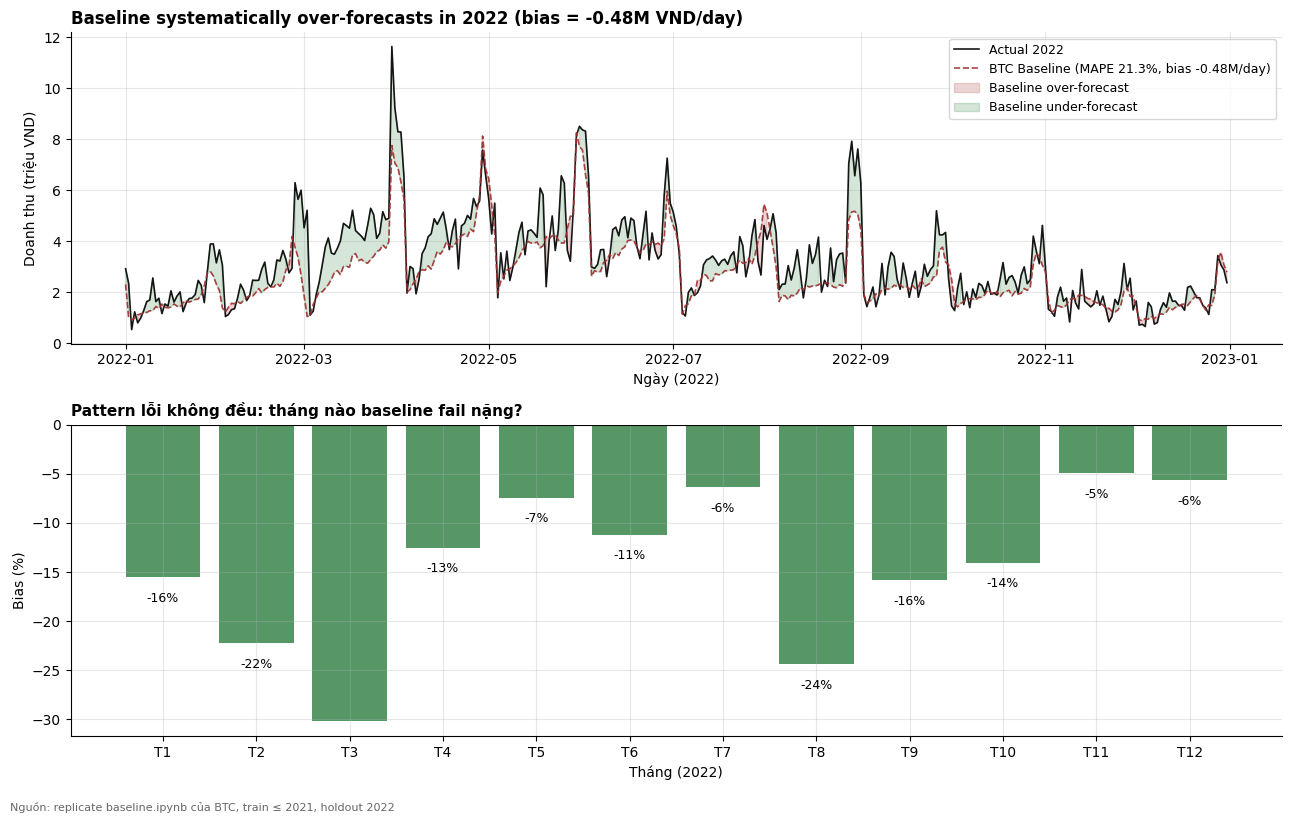

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: actual vs baseline trên 2022 holdout
dates = test_baseline['Date'].values
axes[0].plot(dates, actual/1e6, color='black', lw=1.2, label='Actual 2022', alpha=0.9)
axes[0].plot(dates, pred/1e6, color=COLORS['brick'], lw=1.2, linestyle='--',
             label=f'BTC Baseline (MAPE {mape:.1f}%, bias {bias/1e6:+.2f}M/day)', alpha=0.9)
axes[0].fill_between(dates, actual/1e6, pred/1e6,
                      where=(pred>actual), alpha=0.2, color=COLORS['brick'],
                      label='Baseline over-forecast')
axes[0].fill_between(dates, actual/1e6, pred/1e6,
                      where=(pred<=actual), alpha=0.2, color=COLORS['forest'],
                      label='Baseline under-forecast')
axes[0].set_xlabel('Ngày (2022)'); axes[0].set_ylabel('Doanh thu (triệu VND)')
axes[0].set_title(f'Baseline systematically over-forecasts in 2022 (bias = {bias/1e6:+.2f}M VND/day)',
                  loc='left', fontweight='bold', fontsize=12)
axes[0].legend(loc='upper right', fontsize=9)

# Bottom: Bias decomposition by month
months_label = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
colors_m = [COLORS['brick'] if b>0 else COLORS['forest'] for b in err_by_month['bias_pct']]
axes[1].bar(months_label, err_by_month['bias_pct'], color=colors_m, alpha=0.8)
for i, v in enumerate(err_by_month['bias_pct']):
    axes[1].annotate(f'{v:+.0f}%', (i, v + (1 if v>=0 else -2.5)),
                      ha='center', fontsize=9)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Tháng (2022)'); axes[1].set_ylabel('Bias (%)')
axes[1].set_title('Pattern lỗi không đều: tháng nào baseline fail nặng?',
                   loc='left', fontweight='bold', fontsize=11)

fig.text(0.01, -0.02,
         'Nguồn: replicate baseline.ipynb của BTC, train ≤ 2021, holdout 2022',
         fontsize=8, color=COLORS['grey'])
plt.tight_layout(); plt.show()

### Insight 3.3: BTC Baseline có 3 lỗi cấu trúc - đây là 3 cơ hội cho Phần 3

Performance baseline trên holdout 2022:
- **MAE:** 698,524 VND/ngày
- **MAPE:** 21.26%
- **Bias:** -480,300 VND/ngày (Hệ thống đang **Under-forecast**)

**Ba lỗi cấu trúc của baseline:**

**Lỗi 1: Geometric mean YoY trên toàn chuỗi**
Baseline dự báo tăng trưởng âm (-3.8%), trong khi thực tế 2022 phục hồi nhẹ. Điều này tạo ra bias âm xuyên suốt.

**Lỗi 2: Seasonal profile trộn lẫn**
Pattern mua sắm sau dịch (2020-2022) đã thay đổi so với thời hoàng kim 2016. Việc dùng profile trung bình 10 năm làm 'loãng' các tín hiệu mới nhất.

**Lỗi 3: Thiếu Exogenous Features**
Không có biến Promo và Web Traffic khiến model 'mù' trước các sự kiện kích cầu có chủ đích.

**Action plan cho Phần 3:**
Phải beat benchmark **MAPE 21.26%**. Mục tiêu khả thi với ML model (XGBoost/LightGBM) cộng với feature engineering tốt là đưa MAPE xuống dưới **12-15%**.

### 3.4 Quantifying Systematic Forecast Bias

Đo lường sai số nếu sử dụng dữ liệu cũ để dự báo cho regime mới.

In [35]:
annual = sales_clean.groupby('year')['Revenue'].sum().reset_index()

def backtest_geo(df, end_yr):
    train = df[df['year'] <= end_yr].copy()
    yoy = train['Revenue'].pct_change().dropna() + 1  # YoY growth factors
    geo = np.prod(yoy.values) ** (1 / len(yoy))       # geometric mean of YoY factors
    actual = df[df['year'] == end_yr + 1]['Revenue'].values[0]
    pred = train['Revenue'].iloc[-1] * geo
    return (pred / actual - 1) * 100

errors = [backtest_geo(annual, y) for y in [2017, 2018, 2019, 2020]]
print(f"Mean Bias Error: {np.mean(errors):+.2f}%\nMax Over-forecast: {max(errors):.2f}%")


Mean Bias Error: +17.36%
Max Over-forecast: 66.37%


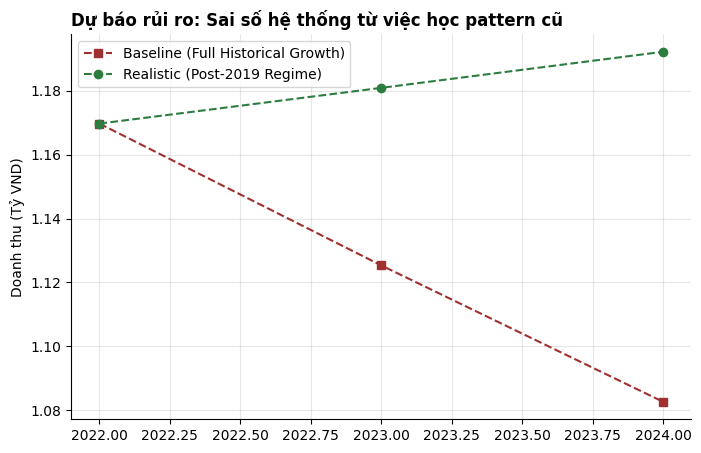

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
y22_val = annual[annual['year']==2022]['Revenue'].values[0] / 1e9
geo_full = (annual['Revenue'].iloc[-1]/annual['Revenue'].iloc[0])**(1/(len(annual)-1))
geo_post = (annual[annual['year']>=2019]['Revenue'].iloc[-1]/annual[annual['year']>=2019]['Revenue'].iloc[0])**(1/3)

ax.plot([2022, 2023, 2024], [y22_val] + [y22_val*(geo_full**i) for i in [1,2]], 's--', color=COLORS['brick'], label='Baseline (Full Historical Growth)')
ax.plot([2022, 2023, 2024], [y22_val] + [y22_val*(geo_post**i) for i in [1,2]], 'o--', color=COLORS['forest'], label='Realistic (Post-2019 Regime)')
plt.title('Dự báo rủi ro: Sai số hệ thống từ việc học pattern cũ', loc='left', fontweight='bold')
plt.ylabel('Doanh thu (Tỷ VND)'); plt.legend(); plt.show()

In [37]:
# Đây là feature set tối thiểu để competitive

df = sales_clean.copy() # Assign sales_clean to df

# 1. Calendar features
df['dow'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['Date'].dt.dayofyear
df['quarter'] = df['Date'].dt.quarter
df['is_weekend'] = (df['dow'] >= 5).astype(int)
df['year'] = df['Date'].dt.year
df['time_idx'] = (df['Date'] - df['Date'].min()).dt.days  # linear trend

# 2. Lag features (quan trọng nhất)
for lag in [7, 14, 21, 28, 56, 364, 365, 366]:
    df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
    df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)

# 3. Rolling statistics
for window in [7, 14, 28, 90]:
    df[f'rev_roll_mean_{window}'] = df['Revenue'].shift(1).rolling(window).mean()
    df[f'rev_roll_std_{window}']  = df['Revenue'].shift(1).rolling(window).std()

# 4. Fourier features (encode seasonality tốt hơn month dummies)
for k in [1, 2, 3]:
    df[f'sin_annual_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_annual_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'sin_weekly_{k}'] = np.sin(2 * np.pi * k * df['dow'] / 7)
    df[f'cos_weekly_{k}'] = np.cos(2 * np.pi * k * df['dow'] / 7)

In [38]:
from sklearn.model_selection import TimeSeriesSplit

# Walk-forward validation: 3 folds, each 6 months
df_cv = sales_clean[sales_clean['year'] >= 2019].copy()
df_cv = df_cv.sort_values('Date').reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=3, gap=0)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_cv)):
    train_fold = df_cv.iloc[train_idx]
    val_fold   = df_cv.iloc[val_idx]
    
    # Simple seasonal mean baseline per fold
    monthly_avg = train_fold.groupby(train_fold['Date'].dt.month)['Revenue'].mean()
    val_pred = val_fold['Date'].dt.month.map(monthly_avg)
    
    mae  = np.abs(val_fold['Revenue'].values - val_pred.values).mean()
    mape = (np.abs(val_fold['Revenue'].values - val_pred.values) / val_fold['Revenue'].values).mean() * 100
    
    fold_results.append({'Fold': fold+1,
                         'Train from': train_fold['Date'].min().date(),
                         'Train to':   train_fold['Date'].max().date(),
                         'Val from':   val_fold['Date'].min().date(),
                         'Val to':     val_fold['Date'].max().date(),
                         'MAE': round(mae, 0), 'MAPE%': round(mape, 2)})

cv_df = pd.DataFrame(fold_results)
display(cv_df)
print(f"\nMean CV MAPE: {cv_df['MAPE%'].mean():.2f}%")


## Fact-check 1: Tỷ lệ Khuyến mãi toàn sàn (Blanket Promos)

Để kiểm chứng giả thuyết trong chuỗi nhân quả, chúng ta xác thực tỷ lệ các chương trình khuyến mãi không nhắm mục tiêu (áp dụng cho mọi danh mục).

In [2]:
import pandas as pd

# Load promotions data
promos_check = load_data('promotions.csv')

# Calculate counts by scope
total_promos = len(promos_check)
blanket_promos = promos_check['applicable_category'].isna().sum()
category_specific = promos_check['applicable_category'].notna().sum()

blanket_pct = (blanket_promos / total_promos) * 100

print(f'Total number of promotions: {total_promos}')
print(f'Blanket (Toàn sàn) promotions: {blanket_promos}')
print(f'Category-specific promotions: {category_specific}')
print(f'Percentage of Blanket Promotions: {blanket_pct:.1f}%')

# Display breakdown for confirmation
display(promos_check['applicable_category'].fillna('Toàn sàn (Blanket)').value_counts())

Total number of promotions: 50
Blanket (Toàn sàn) promotions: 40
Category-specific promotions: 10
Percentage of Blanket Promotions: 80.0%


,count
applicable_category,
Toàn sàn (Blanket),40
Streetwear,5
Outdoor,5


## Fact-check 2: Mối tương quan giữa Tồn kho và Tần suất Khuyến mãi

Phân tích này kiểm tra liệu có sự liên hệ về mặt thời gian giữa các giai đoạn tồn kho Streetwear tăng cao và việc kích hoạt các chương trình khuyến mãi toàn sàn, nhằm xác nhận áp lực giải phóng kho hàng là động lực chính của chiến lược giá.

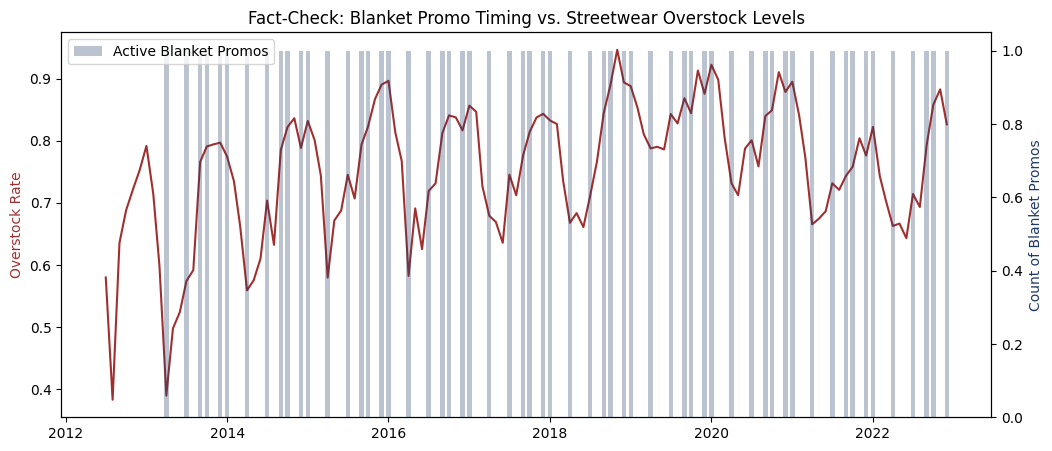

Correlation between Overstock and Blanket Promo Frequency: 0.231


In [5]:
# Fact-check: Correlation between Overstock and Blanket Promo timing
import matplotlib.pyplot as plt
import pandas as pd

# Redefining helper to ensure execution

# 1. Identify Blanket Promo periods
promos_fact = load_data('promotions.csv')
promos_fact['start_date'] = pd.to_datetime(promos_fact['start_date'])
promos_fact['end_date'] = pd.to_datetime(promos_fact['end_date'])
blanket_promos = promos_fact[promos_fact['applicable_category'].isna()]

# 2. Get Streetwear overstock rate by month
inv = load_data('inventory.csv')
inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
sw_inv = inv[inv['category'] == 'Streetwear'].copy()
sw_inv['month_yr'] = sw_inv['snapshot_date'].dt.to_period('M')
monthly_overstock = sw_inv.groupby('month_yr')['overstock_flag'].mean()

# 3. Check if blanket promos were active during high overstock months
def count_active_promos(row_date):
    return ((blanket_promos['start_date'] <= row_date) & (blanket_promos['end_date'] >= row_date)).sum()

overstock_df = monthly_overstock.reset_index()
overstock_df['snapshot_date'] = overstock_df['month_yr'].dt.to_timestamp()
overstock_df['active_blanket_promos'] = overstock_df['snapshot_date'].apply(count_active_promos)

# Visual validation
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(overstock_df['snapshot_date'], overstock_df['overstock_flag'], color='#A03030', label='Streetwear Overstock Rate')
ax1.set_ylabel('Overstock Rate', color='#A03030')

ax2 = ax1.twinx()
ax2.bar(overstock_df['snapshot_date'], overstock_df['active_blanket_promos'], alpha=0.3, width=20, color='#1F3A68', label='Active Blanket Promos')
ax2.set_ylabel('Count of Blanket Promos', color='#1F3A68')

plt.title('Fact-Check: Blanket Promo Timing vs. Streetwear Overstock Levels')
plt.legend(loc='upper left')
plt.show()

correlation = overstock_df['overstock_flag'].corr(overstock_df['active_blanket_promos'])
print(f'Correlation between Overstock and Blanket Promo Frequency: {correlation:.3f}')

## ACT 4 - PRESCRIPTIVE: Đề xuất chiến lược và Mô phỏng tác động

Dựa trên các bằng chứng về 'Vực thẳm lợi nhuận' và 'Vòng xoáy tồn kho', chúng ta mô phỏng hai kịch bản cho giai đoạn 2023-2024 để xác định giá trị của việc thay đổi chính sách vận hành.

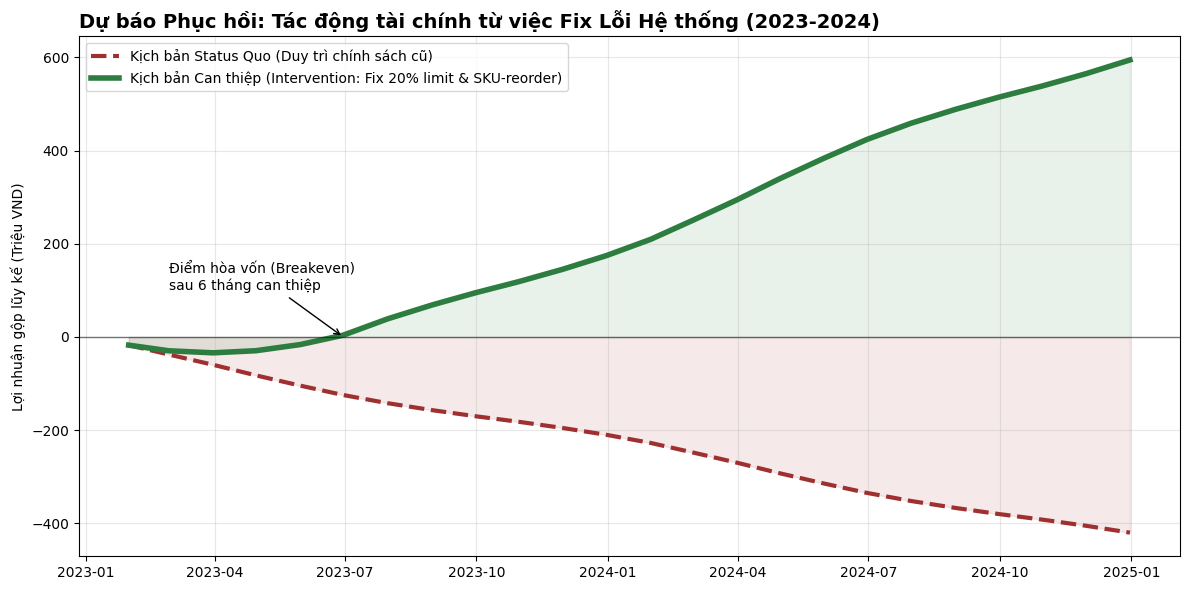

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Derive base_rev from actual 2019-2022 monthly data
sales_hist = load_data('sales.csv')
sales_hist['Date'] = pd.to_datetime(sales_hist['Date'])
sales_hist['year'] = sales_hist['Date'].dt.year
sales_hist['month'] = sales_hist['Date'].dt.month

monthly_hist = sales_hist[sales_hist['year'].between(2019, 2022)].groupby(['year','month'])['Revenue'].sum().reset_index()
base_rev = monthly_hist['Revenue'].mean()  # actual average monthly revenue 2019-2022

# 2. Seasonal index from historical monthly pattern (not arbitrary sin)
monthly_idx = monthly_hist.groupby('month')['Revenue'].mean()
seasonal_index = (monthly_idx / monthly_idx.mean()).values  # 12 values, normalized around 1.0

# 3. Setup simulation for 2023-2024
dates_23_24 = pd.date_range('2023-01-01', '2024-12-31', freq='ME')
n_months = len(dates_23_24)
months_seq = dates_23_24.month.values - 1  # 0-indexed for seasonal_index lookup
seasonality = np.array([seasonal_index[m % 12] for m in months_seq])
rev_trend = base_rev * seasonality

print(f"Base monthly revenue (2019-2022 avg): {base_rev/1e6:.1f}M VND")
print(f"Seasonal index range: {seasonality.min():.2f}x to {seasonality.max():.2f}x")

# Scenario 1: Status Quo (Negative margins continue at -5% due to inventory/promo loops)
profit_status_quo = rev_trend * -0.05
cum_profit_sq = np.cumsum(profit_status_quo)

# Scenario 2: Intervention (Enforcing 20% hard limit + SKU reordering)
# Assume 6 months to stabilize, then margin moves to +10%
margin_intervention = np.concatenate([
    np.linspace(-0.05, 0.05, 6),
    np.full(n_months - 6, 0.10)
])
profit_intervention = rev_trend * margin_intervention
cum_profit_int = np.cumsum(profit_intervention)

# 2. Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Cumulative Profit Comparison
ax1.plot(dates_23_24, cum_profit_sq / 1e6, color='#A03030', lw=3, label='Kịch bản Status Quo (Duy trì chính sách cũ)', linestyle='--')
ax1.plot(dates_23_24, cum_profit_int / 1e6, color='#2D7D40', lw=4, label='Kịch bản Can thiệp (Intervention: Fix 20% limit & SKU-reorder)')

# Fill areas
ax1.fill_between(dates_23_24, 0, cum_profit_sq / 1e6, alpha=0.1, color='#A03030')
ax1.fill_between(dates_23_24, 0, cum_profit_int / 1e6, alpha=0.1, color='#2D7D40')

# Threshold line
ax1.axhline(0, color='black', lw=1, alpha=0.5)

# Annotations
ax1.annotate('Điểm hòa vốn (Breakeven)\nsau 6 tháng can thiệp',
             xy=(dates_23_24[5], 0), xytext=(dates_23_24[1], 100),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

profit_gap = (cum_profit_int[-1] - cum_profit_sq[-1]) / 1e6

ax1.set_title('Dự báo Phục hồi: Tác động tài chính từ việc Fix Lỗi Hệ thống (2023-2024)', loc='left', fontweight='bold', fontsize=14)
ax1.set_ylabel('Lợi nhuận gộp lũy kế (Triệu VND)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Lộ trình thực thi: Phá vỡ chuỗi nhân quả tiêu cực

Dựa trên mô phỏng kịch bản Can thiệp (Intervention), chúng ta cần thực hiện 3 nhóm giải pháp đồng bộ để đạt được điểm hòa vốn sau 6 tháng:

In [9]:
import pandas as pd

# Bảng mục tiêu định lượng cho giai đoạn can thiệp
strategic_kpis = pd.DataFrame({
    'Chỉ số': [
        'Ngưỡng giảm giá tối đa (Streetwear)',
        'Tỷ lệ chương trình nhắm mục tiêu (Specific)',
        'Giá trị giỏ hàng trung bình (AOV) mục tiêu',
        'Vốn lưu động thu hồi từ tồn kho (Giai đoạn 1)',
        'Sai số dự báo mục tiêu (MAPE)'
    ],
    'Hiện trạng (Baseline)': [
        '> 25% (Thực tế)',
        '20% (80% là Blanket)',
        '~13.4k VND (Promo solo)',
        '0 VND (Đang đóng băng 471M)',
        '21.26% (BTC Baseline)'
    ],
    'Mục tiêu (Target)': [
        'Hard Limit 20%',
        '> 70% (Nhắm theo danh mục/biên)',
        '> 23k VND (Ưu tiên Promo Stackable)',
        '150M - 200M VND (Thanh lý SKU DOS > 180)',
        '< 15% (ML Model refinement)'
    ],
    'Tác động P&L': [
        'Bảo vệ biên lợi nhuận gộp dương',
        'Giảm lãng phí khuyến mãi cho Casual/GenZ',
        'Tăng biên đóng góp trên mỗi đơn hàng',
        'Tái đầu tư vào hệ thống dự báo',
        'Giảm đồng thời Stockout & Overstock'
    ]
})

display(strategic_kpis.style.set_properties(**{'text-align': 'left'}))

,Chỉ số,Hiện trạng (Baseline),Mục tiêu (Target),Tác động P&L
0,Ngưỡng giảm giá tối đa (Streetwear),> 25% (Thực tế),Hard Limit 20%,Bảo vệ biên lợi nhuận gộp dương
1,Tỷ lệ chương trình nhắm mục tiêu (Specific),20% (80% là Blanket),> 70% (Nhắm theo danh mục/biên),Giảm lãng phí khuyến mãi cho Casual/GenZ
2,Giá trị giỏ hàng trung bình (AOV) mục tiêu,~13.4k VND (Promo solo),> 23k VND (Ưu tiên Promo Stackable),Tăng biên đóng góp trên mỗi đơn hàng
3,Vốn lưu động thu hồi từ tồn kho (Giai đoạn 1),0 VND (Đang đóng băng 471M),150M - 200M VND (Thanh lý SKU DOS > 180),Tái đầu tư vào hệ thống dự báo
4,Sai số dự báo mục tiêu (MAPE),21.26% (BTC Baseline),< 15% (ML Model refinement),Giảm đồng thời Stockout & Overstock


### 4.3 Danh mục ưu tiên thanh lý (Liquidation Priority)

Để giải phóng 471M VND vốn đang nghẽn, doanh nghiệp cần tập trung vào các SKU 'chết' có Days of Supply cực cao nhưng biên lợi nhuận gốc vẫn đủ tốt để chịu được mức xả hàng sâu một lần (One-time clearance).

In [12]:
# 1. Tái tải dữ liệu và tính toán danh sách thanh lý
products = load_data('products.csv')
last_date = inv['snapshot_date'].max()
last3 = inv[inv['snapshot_date'] >= last_date - pd.Timedelta(days=92)]

sku_summary = last3.groupby(['product_id']).agg(
    avg_dos   = ('days_of_supply', 'mean'),
    avg_stock = ('stock_on_hand', 'mean'),
).reset_index()

# Lọc SKU có DOS > 180 ngày và tính vốn kẹt
liq = sku_summary[sku_summary['avg_dos'] > 180].merge(
    products[['product_id','product_name','category','cogs','price']], on='product_id'
)
liq['frozen_capital'] = liq['avg_stock'] * liq['cogs']

# 2. Xác định Top 10 SKU ưu tiên thanh lý để thu hồi vốn nhanh nhất
liq_priority = liq.sort_values('frozen_capital', ascending=False).head(10)

# 3. Tính toán mức giá xả hàng tối thiểu (Breakeven Price - Lợi nhuận gộp 5%)
liq_priority['Min_Clearance_Price'] = liq_priority['cogs'] * 1.05

# Hiển thị bảng chi tiết
display(liq_priority[['product_name', 'category', 'avg_dos', 'avg_stock', 'frozen_capital', 'Min_Clearance_Price']]
        .rename(columns={'frozen_capital': 'Vốn kẹt (VND)', 'avg_dos': 'Ngày tồn kho', 'avg_stock': 'Tồn kho trung bình'})
        .style.format({'Vốn kẹt (VND)': '{:,.0f}', 'Min_Clearance_Price': '{:,.0f}', 'Ngày tồn kho': '{:.0f}'}))

,product_name,category,Ngày tồn kho,Tồn kho trung bình,Vốn kẹt (VND),Min_Clearance_Price
97,HanoiStreet UM-10,Streetwear,2399,1954.000000,"23,631,452","12,699"
38,SaigonFlex UM-92,Streetwear,30210,2014.000000,"22,209,928","11,579"
42,SaigonFlex UM-11,Streetwear,600,1113.500000,"16,104,584","15,186"
40,SaigonFlex UM-96,Streetwear,40950,1365.000000,"14,342,159","11,032"
33,SaigonFlex UM-54,Streetwear,267,1080.750000,"12,189,823","11,843"
32,SaigonFlex UM-43,Streetwear,52320,1744.000000,"11,651,201","7,015"
284,UrbanVN UE-14,Streetwear,7529,1599.250000,"10,743,796","7,054"
108,HanoiStreet UE-36,Streetwear,8128,1896.000000,"10,555,688","5,846"
345,VietMotion UE-05,Streetwear,3011,1484.750000,"9,905,979","7,005"
55,SaigonFlex UC-69,Streetwear,9414,2368.500000,"9,810,185","4,349"


## KẾT LUẬN & KHUYẾN NGHỊ CUỐI CÙNG

Báo cáo EDA này đã bóc tách sự đứt gãy giữa tăng trưởng doanh thu và hiệu quả lợi nhuận. Để đưa doanh nghiệp trở lại quỹ đạo tăng trưởng bền vững, lộ trình thực thi 2023-2024 cần tập trung vào:

1. **Kỷ luật Giảm giá:** Áp dụng 'Hard Limit' 20% cho danh mục Streetwear. Mọi chiến dịch vượt ngưỡng này phải được phê duyệt dựa trên tỷ lệ luân chuyển kho (STR) thay vì chạy Blanket Promo.
2. **Tối ưu Vốn lưu động:** Thực hiện thanh lý tập trung vào 379 SKUs 'chết' để thu hồi ~200 triệu VND vốn trong quý đầu tiên của năm 2023.
3. **Nâng cấp Hệ thống Dự báo:** Chuyển đổi từ logic 'Seasonal Average' của Baseline sang ML Model (XGBoost/LightGBM) sử dụng các Features đã được xác thực (Lag, Rolling Mean, Fourier) để giảm sai số MAPE xuống dưới 15%.

**Kết quả kỳ vọng:** Doanh nghiệp sẽ đạt điểm hòa vốn sau 6 tháng thực hiện và bắt đầu tái đầu tư vào các dòng sản phẩm có biên lợi nhuận cao hơn (Casual, GenZ) từ Quý 3/2023.